# Goal: Create Extended Data Fig. 4 plots

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse

import session_info
session_info.show()

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')`

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['pdf.fonttype'] = 42

save_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Summary_plots/'

# 1. Prepare CD8 T cell plots

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata_CD8.h5ad')
adata

AnnData object with n_obs × n_vars = 1474601 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/CD8_umap_neighbors_30_min_dist_1.3.npy')
adata.obsm["X_umap"] = UMAP

In [5]:
motif_df=pd.read_csv("/rfs/project/rfs-iCNyzSAaucw/lmd76/code_hpc/data/disease_associated_motifs_hla.csv", index_col='Unnamed: 0')
motif_df

,motif,n_cells,n_unique_vdj_clones,n_beam_cells,n_donors,n_studies,majority_pathogen,majority_pathogen_unique_clone_frac,majority_annotation,majority_annotation_all_cells_frac,...,majority_vdjdb_organism,n_vdjdb_epitopes,majority_beam_epitope,majority_beam_organism,majority_beam_cells_frac,MHC_I_restricted_allele,MHC_II_restricted_allele,majority_vdjdb_organism_simple,predicted_pathogen,predicted_pathogen_source
0,592,3099,2,544,6,2,EBV_VZV,0.500000,T CD8 EF,0.964557,...,NaN,NaN,IE62,VZV,0.505515,Multiple,Multiple,NaN,VZV,beam
1,37,2729,43,11,41,12,SARS-CoV-2,0.490196,T CD8 EF,0.843166,...,Human herpesvirus 5 (Human cytomegalovirus),2.0,NLVPMVATV,CMV,1.000000,A*02:01,Not restricted,CMV,CMV,beam
2,61,2714,17,0,6,1,HPV,1.000000,T CD8 EX,0.771186,...,SARS-CoV2,1.0,NaN,NaN,NaN,Not restricted,Not restricted,SARS-CoV-2,HPV,majority_pathogen
8,565,1444,1,0,6,2,SARS-CoV-2,1.000000,T CD8 EF,0.922438,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Not restricted,NaN,SARS-CoV-2,majority_pathogen
10,25,1156,82,0,73,10,SARS-CoV-2,0.507246,T CD8 EF,0.782872,...,Human herpesvirus 5 (strain RV798),8.0,NaN,NaN,NaN,Not restricted,Not restricted,CMV,CMV,vdjdb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1115,4,1,0,4,2,NaN,0.000000,T CD4 CM,1.000000,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Multiple,NaN,NaN,NaN
1064,1124,4,1,0,4,3,SARS-CoV-2,1.000000,T CD4 CM,0.500000,...,SARS-CoV2,1.0,NaN,NaN,NaN,C*07:02,DRB1*15:01,SARS-CoV-2,SARS-CoV-2,majority_pathogen
1067,1223,4,1,0,4,4,SARS-CoV-2,0.500000,T CD8 CM,0.666667,...,SARS-CoV2,1.0,NaN,NaN,NaN,Multiple,Not restricted,SARS-CoV-2,SARS-CoV-2,vdjdb
1068,1243,4,1,0,4,1,SARS-CoV-2,1.000000,T CD8 EF,0.750000,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Not restricted,NaN,SARS-CoV-2,majority_pathogen


In [6]:
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection_cell2tcr/cell2tcr_job/clone_df_with_motif_21.csv', index_col='Unnamed: 0')
#adata = adata[adata.obs_names.isin(df.index)]
#adata.obs['motif'] = df.loc[adata.obs_names, 'motif'].values

adata.obs['motif'] = df['motif'].reindex(adata.obs_names).values

/tmp/ipykernel_645243/3504749257.py:1: DtypeWarning: Columns (13,15,17,19,23,24,25,28,29,30,40,42,50,54,56,61,62,63,64,67,68,70,71,72,73,75,76,77,79,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection_cell2tcr/cell2tcr_job/clone_df_with_motif_21.csv', index_col='Unnamed: 0')


In [7]:
adata.obs['predicted_pathogen'] = adata.obs['motif'].map(
    motif_df.set_index('motif')['predicted_pathogen']
)

In [8]:
adata.obs['motif'] = df['motif'].reindex(adata.obs_names).astype('Int64').astype(str).replace('<NA>', 'nan').values

In [10]:
# build motif -> pathogen mapping
motif_to_pathogen = (
    adata.obs[['motif', 'predicted_pathogen']]  # adjust column name if different
    .dropna()
    .drop_duplicates('motif')
    .set_index('motif')['predicted_pathogen']
    .to_dict()
)

- create TCR motif overview across major CD8+ T cell differentiation branches:

['T CD8 EF', 'T CD8 Activated', 'T CD8 EX']


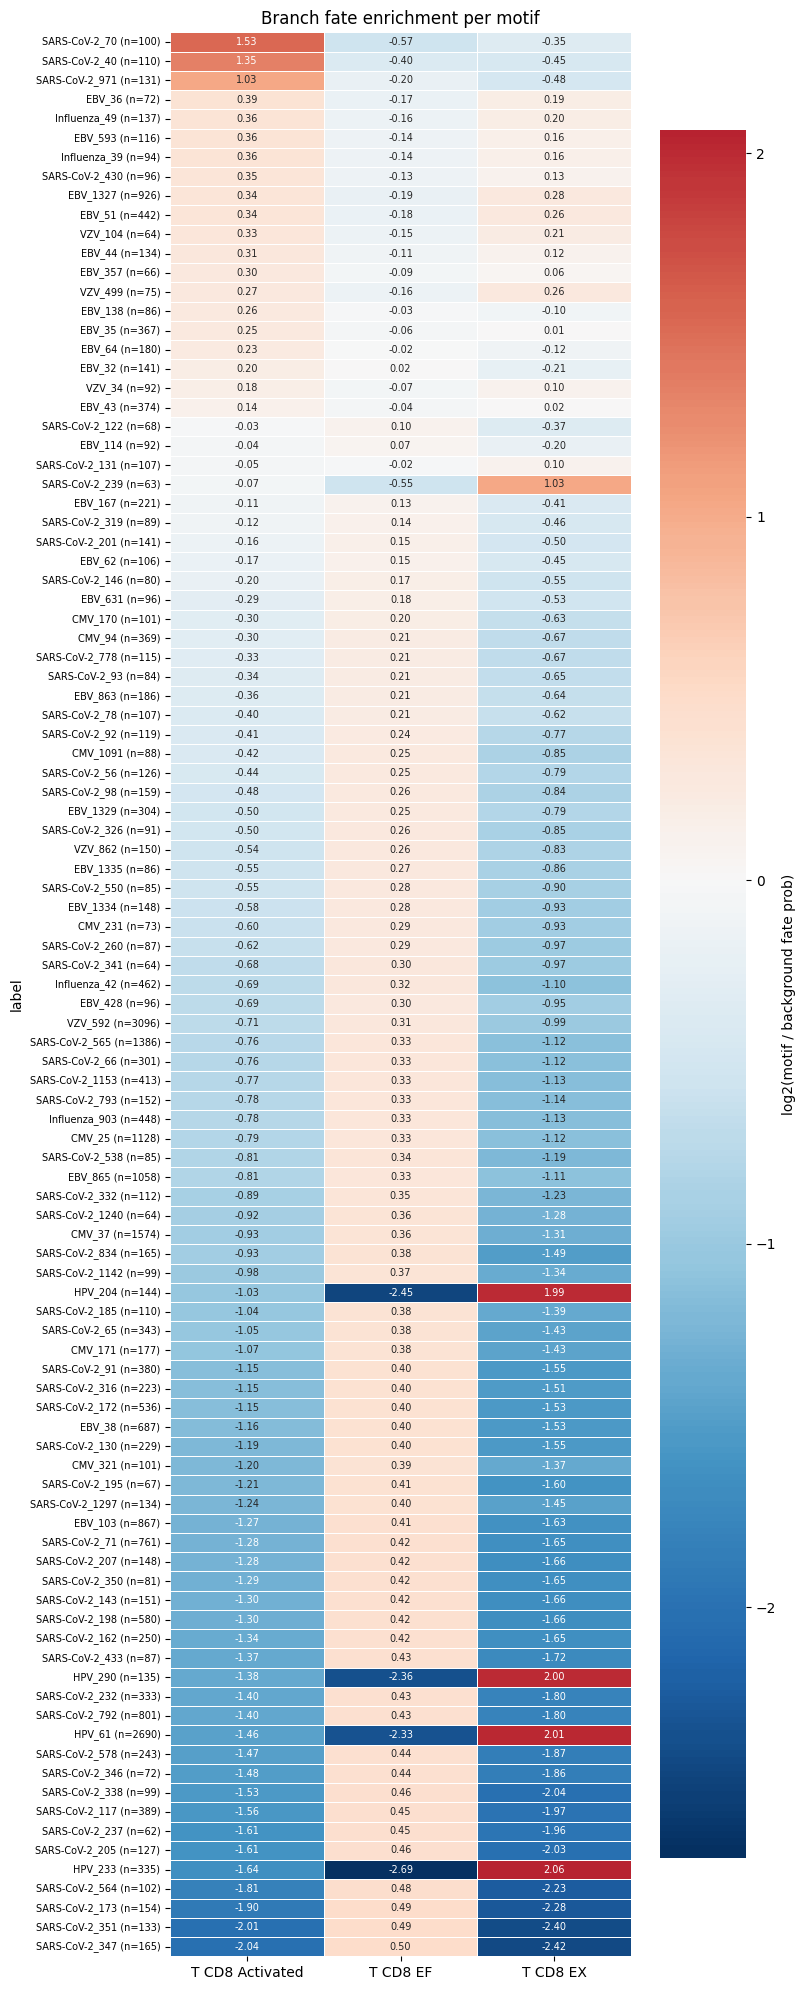

In [25]:
branches = fate_probs.columns.tolist()
print(branches)  # confirm: ['T CD8 EF', 'T CD8 Activated', 'T CD8 EX']

motifs_of_interest = [
    m for m in adata.obs['motif'].value_counts().index
    if m != 'nan' and motif_to_pathogen.get(m, 'unknown') != 'unknown'
][:100]

results = []
for motif in motifs_of_interest:
    mask = adata.obs['motif'] == motif
    n_cells = mask.sum()
    motif_mean = fate_probs[mask].mean()
    background_mean = fate_probs[~mask].mean()
    enrichment = np.log2((motif_mean + 0.01) / (background_mean + 0.01))
    pathogen = motif_to_pathogen.get(motif, 'unknown')
    
    for branch in branches:
        results.append({
            'motif': motif,
            'label': f"{pathogen}_{motif} (n={n_cells})",
            'branch': branch,
            'log2_enrichment': enrichment[branch],
            'mean_fate_prob': motif_mean[branch],
            'n_cells': n_cells,
            'pathogen': pathogen
        })

results_df = pd.DataFrame(results)
pivot = results_df.drop_duplicates(['label', 'branch']).pivot(
    index='label', columns='branch', values='log2_enrichment'
)
pivot = pivot.sort_values('T CD8 Activated', ascending=False)

fig, ax = plt.subplots(figsize=(8, 20))
sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'log2(motif / background fate prob)'},
            linewidths=0.5, ax=ax,
            yticklabels=True,
            annot_kws={'size': 7})
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.title('Branch fate enrichment per motif')
plt.xlabel('')
plt.tight_layout()
plt.show()

- Define query functions to visualise pathogen-associated TCR motifs:

In [11]:
def plot_motif_umap(adata, motif, color='purple', fg_size=25,
                    title=None, save=None, figsize=(6,6), ax=None):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    umap_coords = adata.obsm['X_umap']
    mask = adata.obs['motif'].values == motif
    
    # background - only plot if no ax passed in
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
               s=bg_size, color='lightgrey', rasterized=True)
    
    # overlay motif cells
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               s=fg_size, color=color, zorder=3,
               label=f'{motif_to_pathogen.get(motif, "")}_{motif} (n={mask.sum()})')
    
    ax.legend(frameon=False, loc='lower right')
    ax.set_title(title or f'{motif_to_pathogen.get(motif, "")}_{motif}')
    ax.axis('off')
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


# pre-render background once, then reuse
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)
ax.axis('off')

# save background figure to reuse
import pickle
with open('/tmp/bg_fig.pkl', 'wb') as f:
    pickle.dump(fig, f)
plt.close()

# usage - loads background and overlays motif
def plot_motif_umap(adata, motif, color='purple', fg_size=25,
                    title=None, save=None):
    
    with open('/tmp/bg_fig.pkl', 'rb') as f:
        fig = pickle.load(f)
    ax = fig.axes[0]
    
    umap_coords = adata.obsm['X_umap']
    mask = adata.obs['motif'].values == motif
    label = f'{motif_to_pathogen.get(motif, "")}_{motif} (n={mask.sum()})'
    
    scatter = ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                         s=fg_size, color=color, zorder=3, label=label)
    
    ax.legend(frameon=False, loc='lower right')
    ax.set_title(title or label)
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    
    # remove overlay for next call
    scatter.remove()
    if ax.get_legend():
        ax.get_legend().remove()

In [12]:
import matplotlib.cm as cm

cats = adata.obs['annotation_level_3'].cat.categories.tolist()

# generate custom colors for all categories
custom_colors = cm.Set3(np.linspace(0, 1, len(cats)))
color_map = dict(zip(cats, custom_colors))
color_map['Other (<1.0%)'] = 'lightgrey'

def plot_annotation_barplot(adata, motifs, title='', figsize=(6, 3), save=None, min_frac=0.025):
    """
    Plot annotation_level_3 horizontal stacked barplot for a list of motifs.
    motifs: list of motif IDs or a single motif string
    """
    if isinstance(motifs, str):
        motifs = [motifs]
    
    mask = adata.obs['motif'].isin(motifs)
    counts = adata.obs[mask]['annotation_level_3'].value_counts()
    fracs = counts / counts.sum()
    
    # collapse rare categories
    major = fracs[fracs >= min_frac]
    rare = fracs[fracs < min_frac]
    if len(rare) > 0:
        major['Other (<1.0%)'] = rare.sum()
    
    fig, ax = plt.subplots(figsize=figsize)
    left = 0
    for cat, val in major.items():
        color = color_map.get(cat, 'lightgrey')
        ax.barh(0, val, left=left, color=color,
                edgecolor='white', linewidth=0.5, label=cat)
        left += val
    
    ax.set_xlabel('Fraction of cells')
    ax.set_title(f'{title} (n={mask.sum()} cells)')
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.legend(bbox_to_anchor=(1.05, 1), frameon=False,
              title='annotation_level_3', fontsize=8)
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

- Visualise selected TCR motifs:

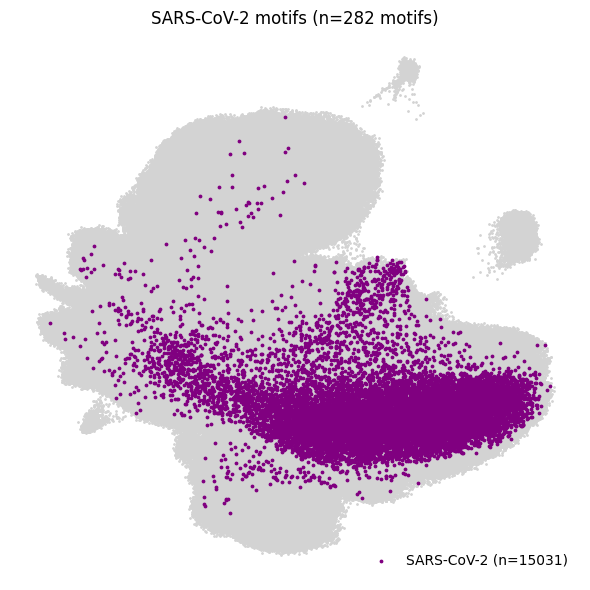

In [36]:
# All SARS-CoV-2 associated TCR motifs

fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']

sars_motifs = [m for m, p in motif_to_pathogen.items() if p == 'SARS-CoV-2']
mask_all = adata.obs['motif'].isin(sars_motifs)

# background
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)

# all SARS-CoV-2 motif cells on top
ax.scatter(umap_coords[mask_all, 0], umap_coords[mask_all, 1],
           s=3, color='purple', zorder=3,
           label=f'SARS-CoV-2 (n={mask_all.sum()})')

ax.legend(frameon=False, loc='lower right')
ax.set_title(f'SARS-CoV-2 motifs (n={len(sars_motifs)} motifs)')
ax.axis('off')
plt.tight_layout()
plt.savefig(save_dir+'T_CD8_motif_SARS_CoV_2_all.pdf', dpi=150, bbox_inches='tight')
plt.show()

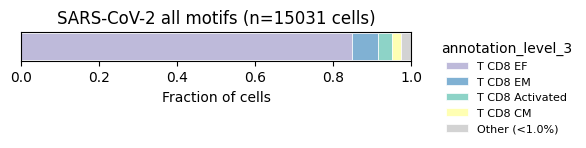

In [67]:
plot_annotation_barplot(adata, motifs=sars_motifs,
                        min_frac=0.01,
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 all motifs',
                        save=save_dir+'barplot_SARS_CoV_2_all.pdf')

- Ext Data Fig 4c-d

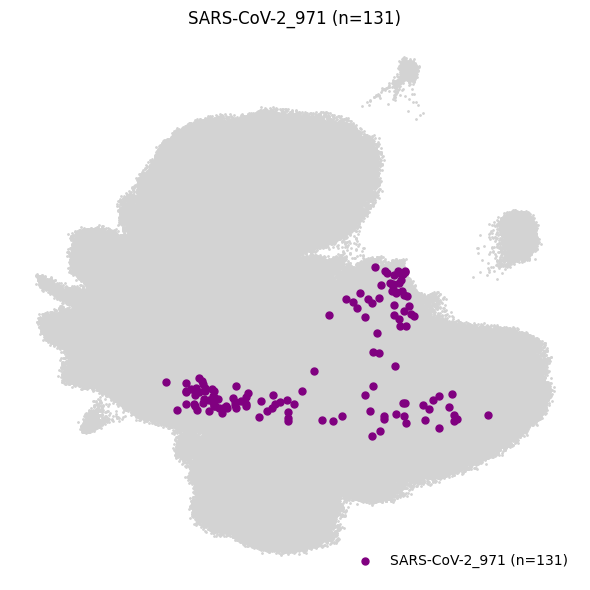

In [272]:
plot_motif_umap(adata, motif='971', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_example_1.pdf')

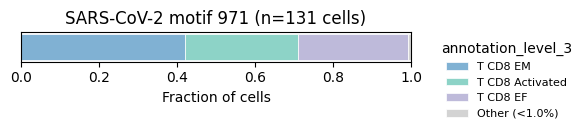

In [68]:
plot_annotation_barplot(adata, motifs='971',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 971',
                        save=save_dir+'barplot_SARS_CoV_2_971.pdf')

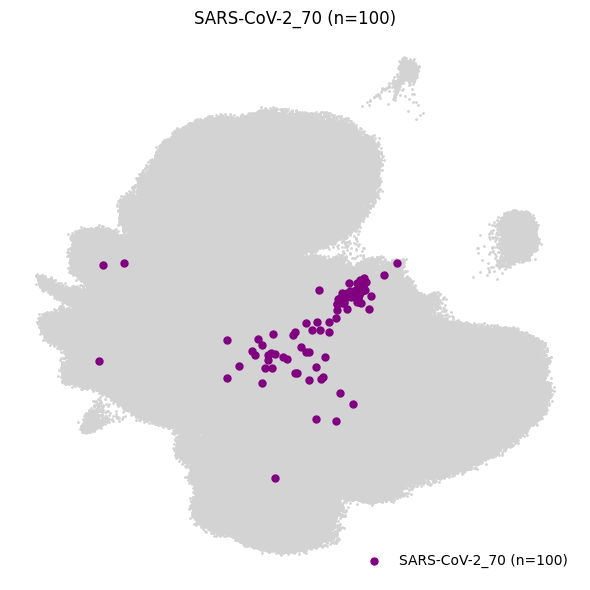

In [21]:
plot_motif_umap(adata, motif='70', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_70.pdf')

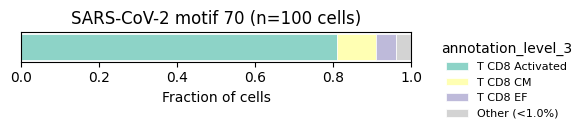

In [22]:
plot_annotation_barplot(adata, motifs='70',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 70',
                        save=save_dir+'barplot_SARS_CoV_2_70.pdf')

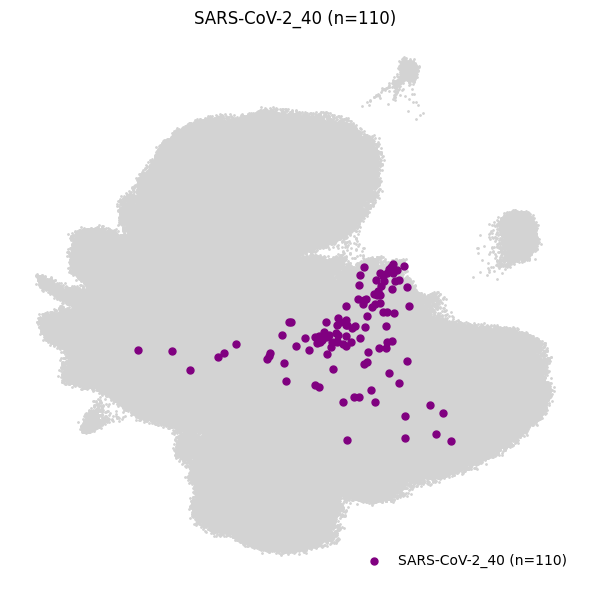

In [23]:
plot_motif_umap(adata, motif='40', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_40.pdf')

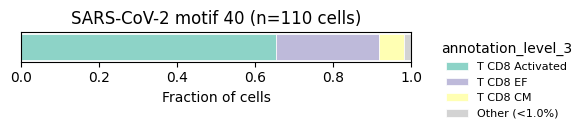

In [24]:
plot_annotation_barplot(adata, motifs='40',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 40',
                        save=save_dir+'barplot_SARS_CoV_2_40.pdf')

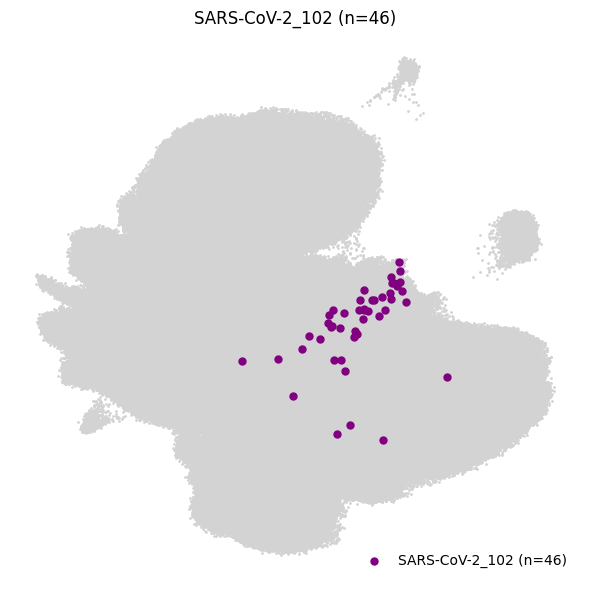

In [25]:
plot_motif_umap(adata, motif='102', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_102.pdf')

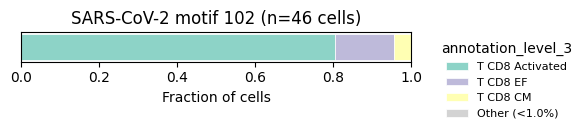

In [26]:
plot_annotation_barplot(adata, motifs='102',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 102',
                        save=save_dir+'barplot_SARS_CoV_2_102.pdf')

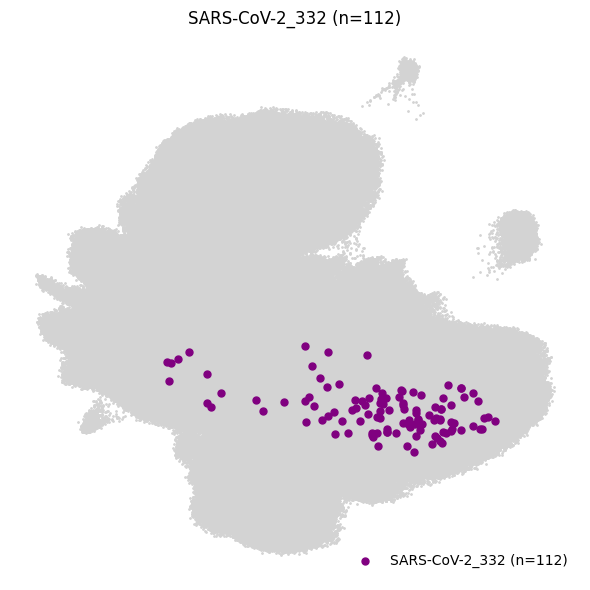

In [20]:
plot_motif_umap(adata, motif='332', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_example_3.pdf')

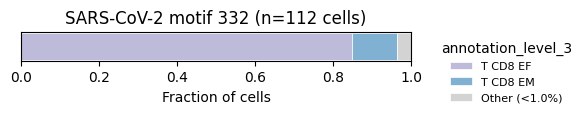

In [70]:
plot_annotation_barplot(adata, motifs='332',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 332',
                        save=save_dir+'barplot_SARS_CoV_2_332.pdf')

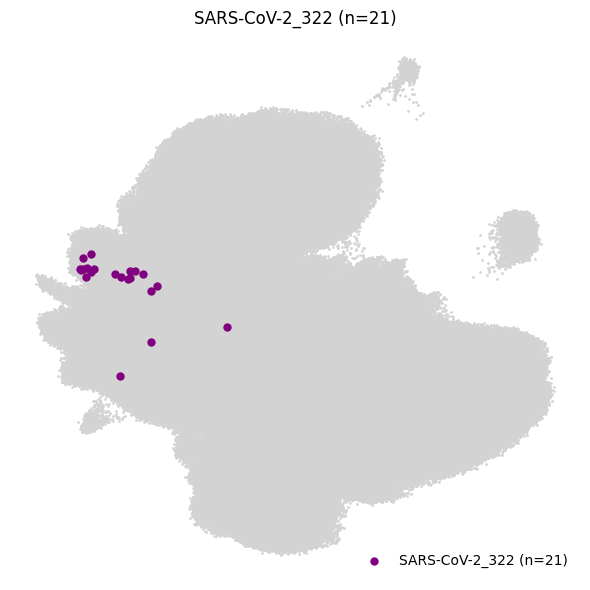

In [24]:
plot_motif_umap(adata, motif='322', color='purple', fg_size=25, save=save_dir+'T_CD8_motif_SARS_CoV_2_example_4.pdf')

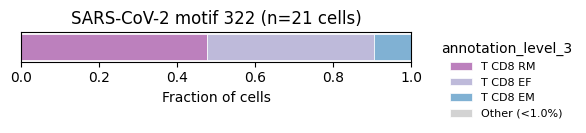

In [71]:
plot_annotation_barplot(adata, motifs='322',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 322',
                        save=save_dir+'barplot_SARS_CoV_2_322.pdf')

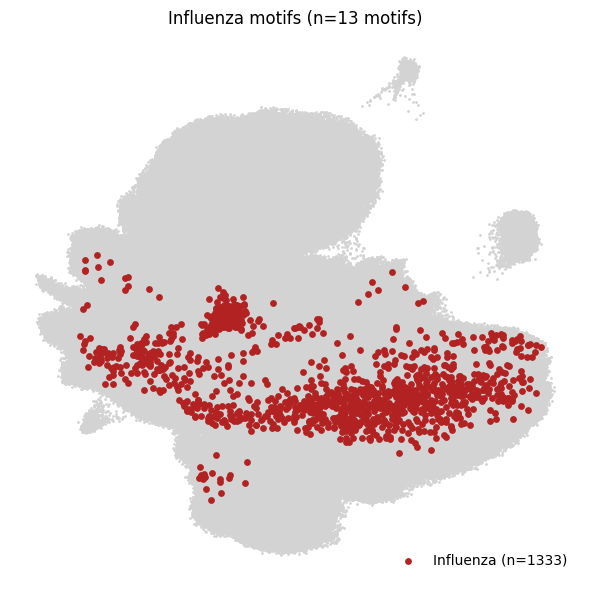

In [101]:
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']

sars_motifs = [m for m, p in motif_to_pathogen.items() if p == 'Influenza']
mask_all = adata.obs['motif'].isin(sars_motifs)

# background
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)

# all SARS-CoV-2 motif cells on top
ax.scatter(umap_coords[mask_all, 0], umap_coords[mask_all, 1],
           s=15, color='firebrick', zorder=3,
           label=f'Influenza (n={mask_all.sum()})')

ax.legend(frameon=False, loc='lower right')
ax.set_title(f'Influenza motifs (n={len(sars_motifs)} motifs)')
ax.axis('off')
plt.tight_layout()
plt.savefig(save_dir+'T_CD8_motif_Influenza_virus_all.pdf', dpi=150, bbox_inches='tight')
plt.show()

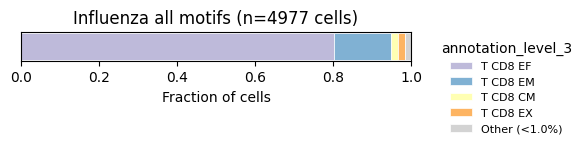

In [100]:
plot_annotation_barplot(adata, motifs=sars_motifs,
                        min_frac=0.01,
                        figsize=(6, 1.25),
                        title='Influenza all motifs',
                        save=save_dir+'barplot_Influenza_all.pdf'
                        )

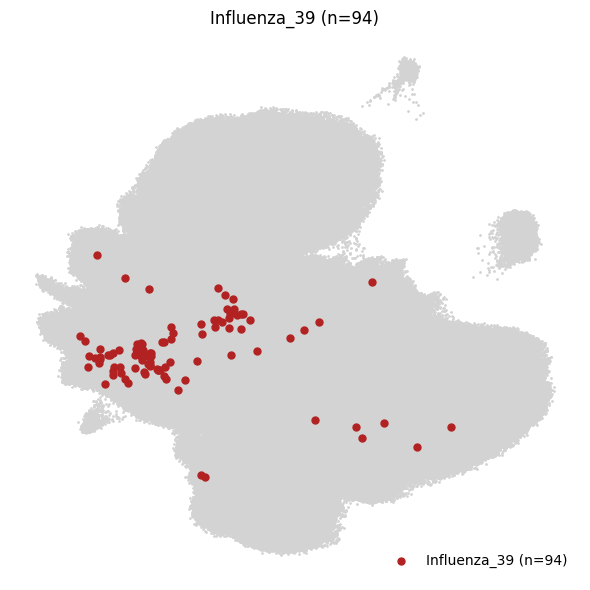

In [104]:
plot_motif_umap(adata, motif='39', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza_39.pdf')

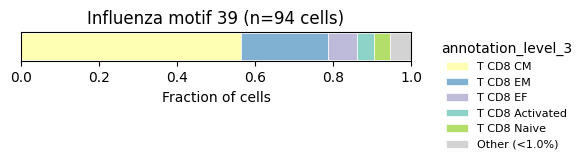

In [105]:
plot_annotation_barplot(adata, motifs='39',
                        figsize=(6, 1.25),
                        title='Influenza motif 39',
                        save=save_dir+'barplot_Influenza_39.pdf')

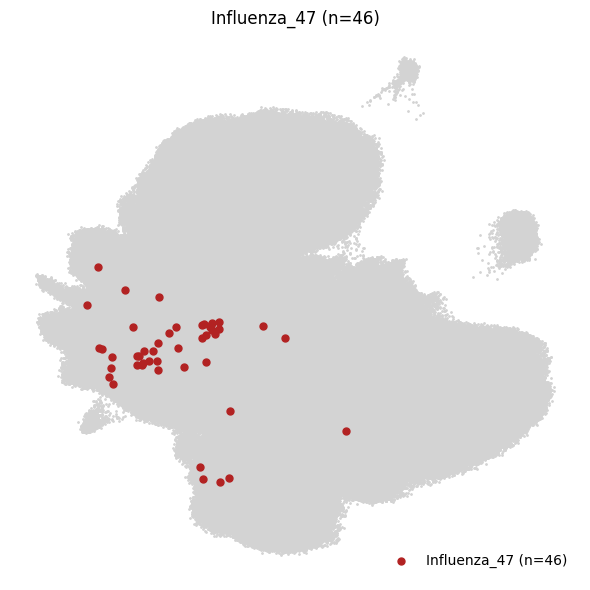

In [88]:
plot_motif_umap(adata, motif='47', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza.pdf')

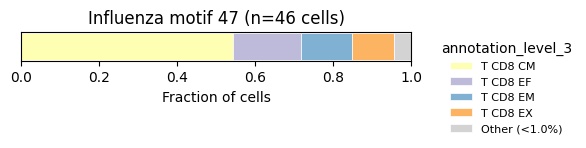

In [92]:
plot_annotation_barplot(adata, motifs='47',
                        figsize=(6, 1.25),
                        title='Influenza motif 47')


#save=save_dir+'barplot_SARS_CoV_2_322.pdf'

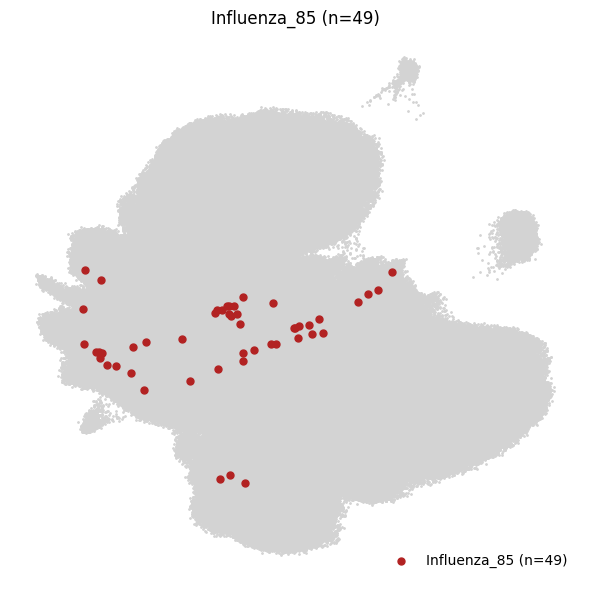

In [103]:
plot_motif_umap(adata, motif='85', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza_85.pdf')

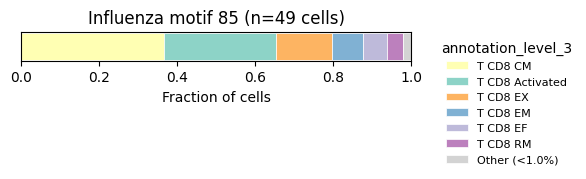

In [102]:
plot_annotation_barplot(adata, motifs='85',
                        figsize=(6, 1.25),
                        title='Influenza motif 85',
                        save=save_dir+'barplot_Inlfuenza_85.pdf')

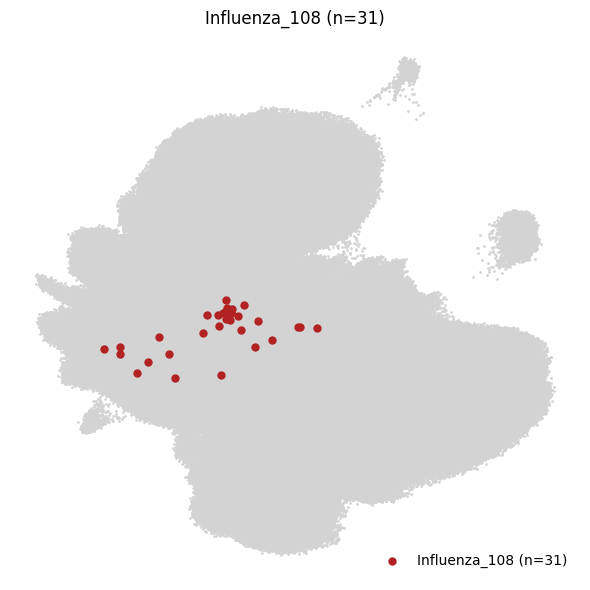

In [106]:
plot_motif_umap(adata, motif='108', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza_108.pdf')

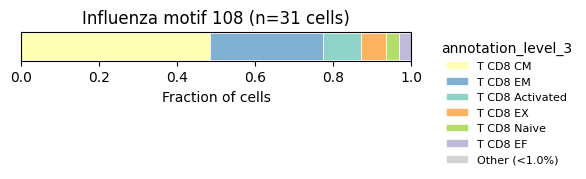

In [112]:
plot_annotation_barplot(adata, motifs='108',
                        figsize=(6, 1.25),
                        title='Influenza motif 108',
                        save=save_dir+'barplot_Influenza_108.pdf')

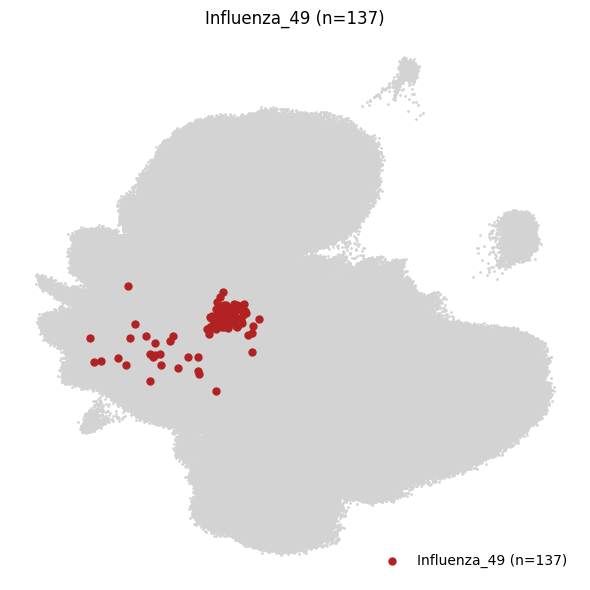

In [84]:
plot_motif_umap(adata, motif='49', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza.pdf')

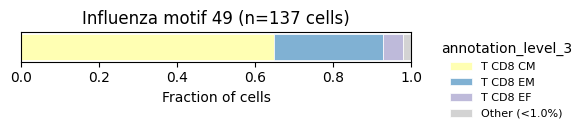

In [95]:
plot_annotation_barplot(adata, motifs='49',
                        figsize=(6, 1.25),
                        title='Influenza motif 49')


#save=save_dir+'barplot_SARS_CoV_2_322.pdf'

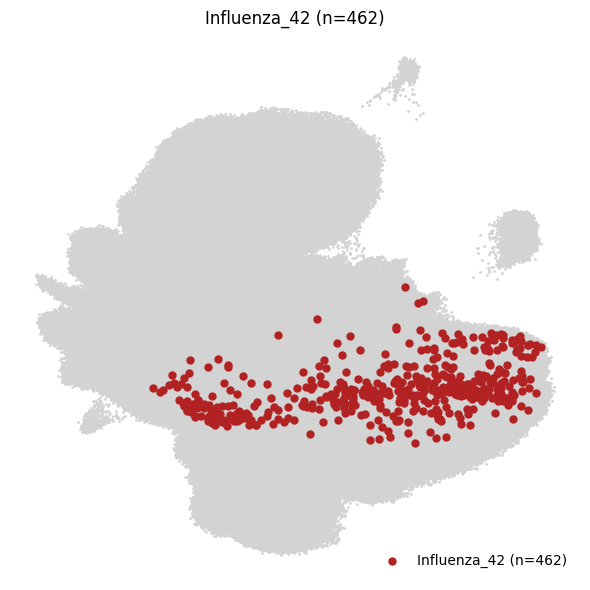

In [108]:
plot_motif_umap(adata, motif='42', color='firebrick', fg_size=25, save=save_dir+'T_CD8_motif_Influenza_42.pdf')

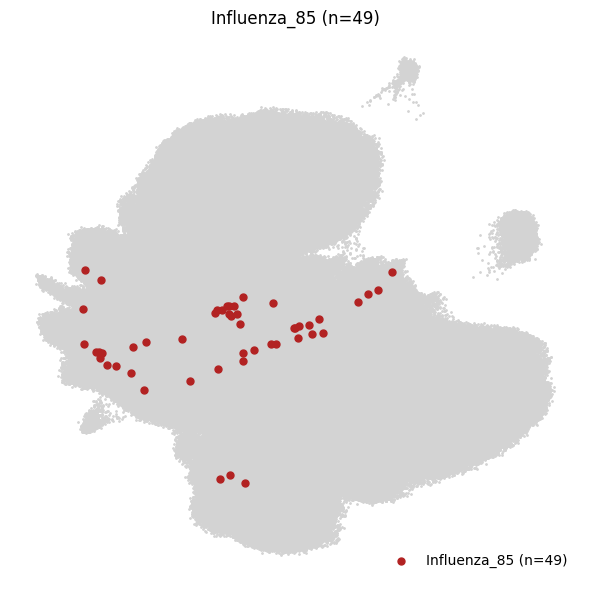

In [116]:
plot_motif_umap(adata, motif='85', color='firebrick', fg_size=25)

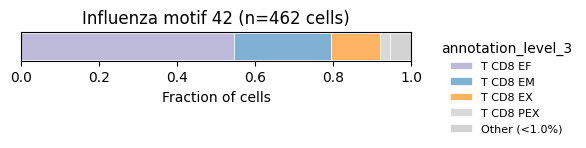

In [111]:
plot_annotation_barplot(adata, motifs='42',
                        figsize=(6, 1.25),
                        title='Influenza motif 42',
                        save=save_dir+'barplot_Influenza_42.pdf')

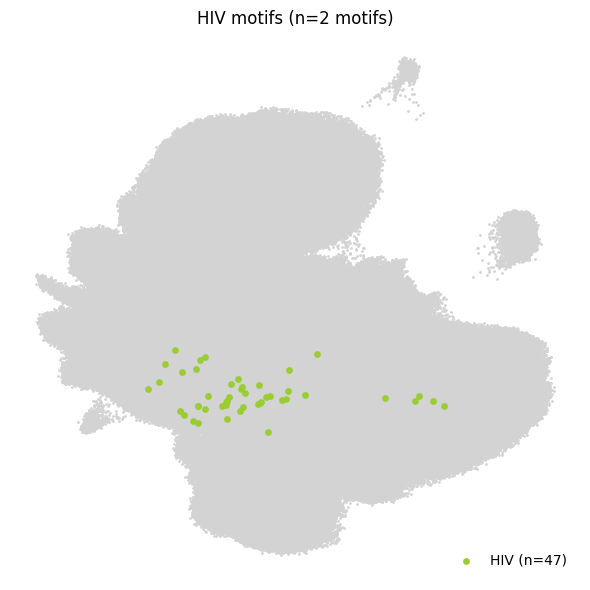

In [97]:
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']

sars_motifs = [m for m, p in motif_to_pathogen.items() if p == 'HIV']
mask_all = adata.obs['motif'].isin(sars_motifs)

# background
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)

# all SARS-CoV-2 motif cells on top
ax.scatter(umap_coords[mask_all, 0], umap_coords[mask_all, 1],
           s=15, color='yellowgreen', zorder=3,
           label=f'HIV (n={mask_all.sum()})')

ax.legend(frameon=False, loc='lower right')
ax.set_title(f'HIV motifs (n={len(sars_motifs)} motifs)')
ax.axis('off')
plt.tight_layout()
#plt.savefig(save_dir+'T_CD8_motif_Influenza_virus_all.pdf', dpi=150, bbox_inches='tight')
plt.show()

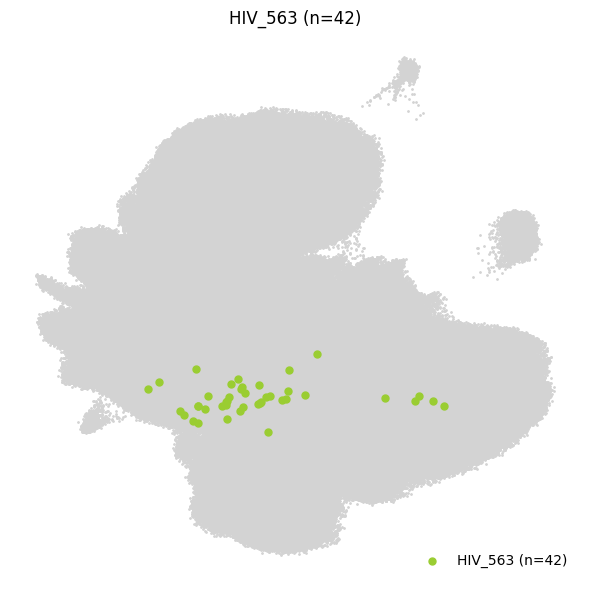

In [117]:
plot_motif_umap(adata, motif='563', color='yellowgreen', fg_size=25, save=save_dir+'T_CD8_motif_HIV_563.pdf')

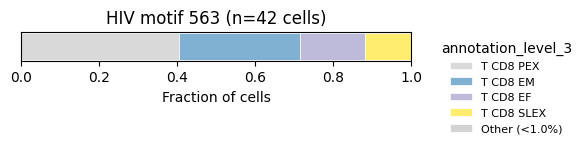

In [121]:
plot_annotation_barplot(adata, motifs='563',
                        figsize=(6, 1.25),
                        title='HIV motif 563',
                        save=save_dir+'barplot_HIV_563.pdf')

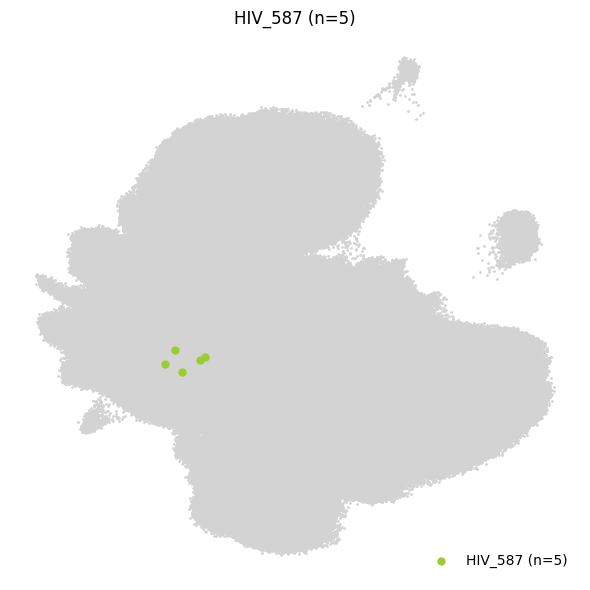

In [123]:
plot_motif_umap(adata, motif='587', color='yellowgreen', fg_size=25, save=save_dir+'T_CD8_motif_HIV_587.pdf')

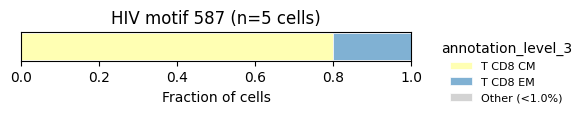

In [124]:
plot_annotation_barplot(adata, motifs='587',
                        figsize=(6, 1.25),
                        title='HIV motif 587',
                        save=save_dir+'barplot_HIV_587.pdf')

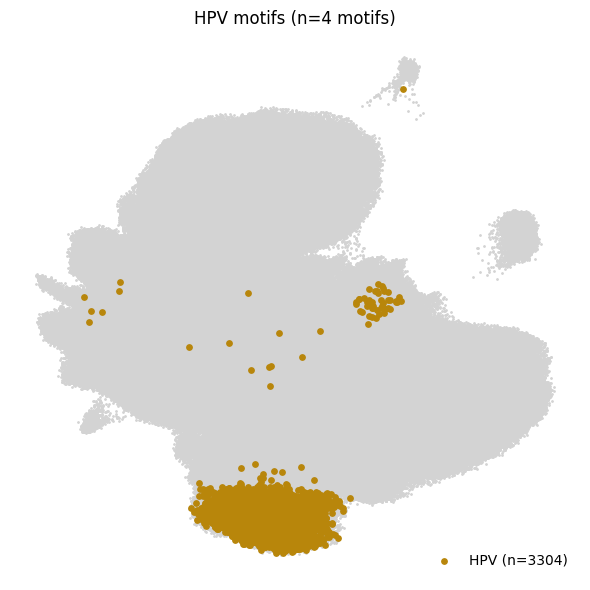

In [98]:
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']

sars_motifs = [m for m, p in motif_to_pathogen.items() if p == 'HPV']
mask_all = adata.obs['motif'].isin(sars_motifs)

# background
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)

# all SARS-CoV-2 motif cells on top
ax.scatter(umap_coords[mask_all, 0], umap_coords[mask_all, 1],
           s=15, color='darkgoldenrod', zorder=3,
           label=f'HPV (n={mask_all.sum()})')

ax.legend(frameon=False, loc='lower right')
ax.set_title(f'HPV motifs (n={len(sars_motifs)} motifs)')
ax.axis('off')
plt.tight_layout()
#plt.savefig(save_dir+'T_CD8_motif_Influenza_virus_all.pdf', dpi=150, bbox_inches='tight')
plt.show()

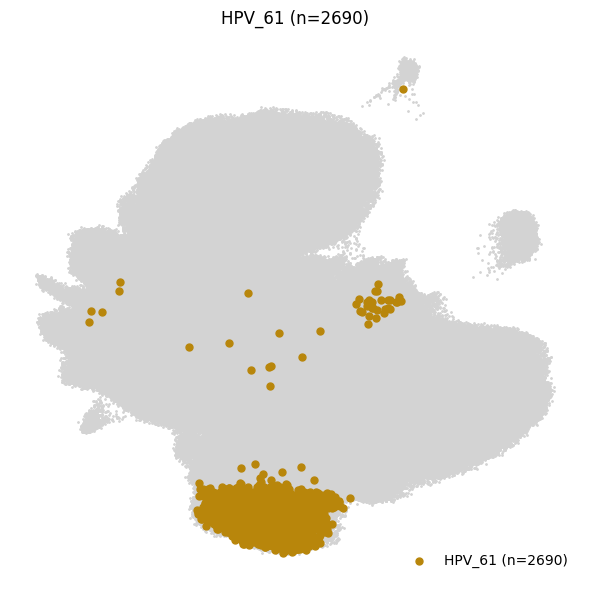

In [119]:
plot_motif_umap(adata, motif='61', color='darkgoldenrod', fg_size=25, save=save_dir+'T_CD8_motif_HPV_61.pdf')

In [150]:
mask = adata.obs['motif'] == '61'
counts = adata.obs[mask]['annotation_level_3'].value_counts()
fracs = counts / counts.sum()

print(f"HPV motif 61 (n={mask.sum()} cells)")
print("-" * 40)
for cat, frac in fracs.items():
    print(f"{cat:<25} {frac:.3f} ({counts[cat]} cells)")

HPV motif 61 (n=2690 cells)
----------------------------------------
T CD8 EX                  0.778 (2093 cells)
T CD8 SLEX                0.101 (271 cells)
T CD8 Activated           0.076 (205 cells)
T CD8 PEX                 0.038 (101 cells)
T CD8 EF                  0.002 (6 cells)
T CD8 RM                  0.002 (6 cells)
T CD8 CM                  0.001 (4 cells)
T CD8 EM                  0.001 (2 cells)
T CD8 Reg                 0.001 (2 cells)
T CD8 EF KIR              0.000 (0 cells)
T CD8 Naive RTE           0.000 (0 cells)
T CD8 Naive               0.000 (0 cells)


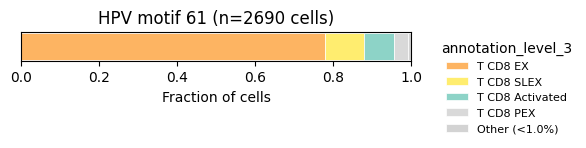

In [128]:
plot_annotation_barplot(adata, motifs='61',
                        figsize=(6, 1.25),
                        title='HPV motif 61',
                        save=save_dir+'barplot_HPV_61.pdf')

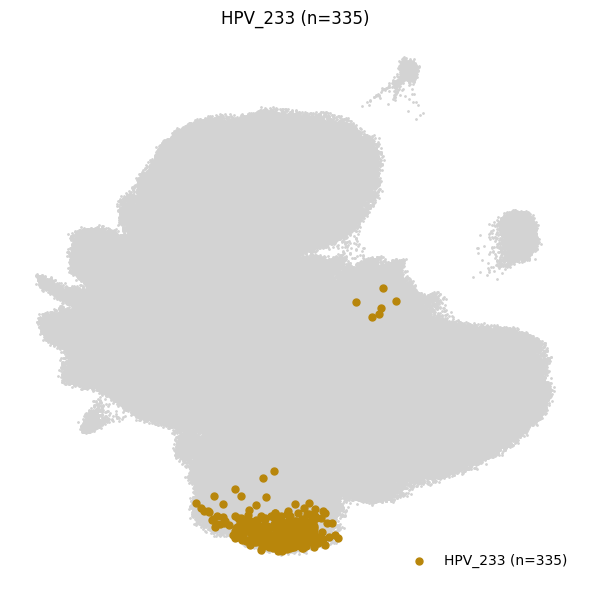

In [126]:
plot_motif_umap(adata, motif='233', color='darkgoldenrod', fg_size=25, save=save_dir+'T_CD8_motif_HPV_233.pdf')

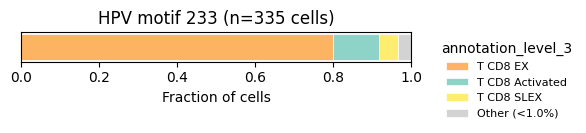

In [127]:
plot_annotation_barplot(adata, motifs='233',
                        figsize=(6, 1.25),
                        title='HPV motif 233',
                        save=save_dir+'barplot_HPV_233.pdf')

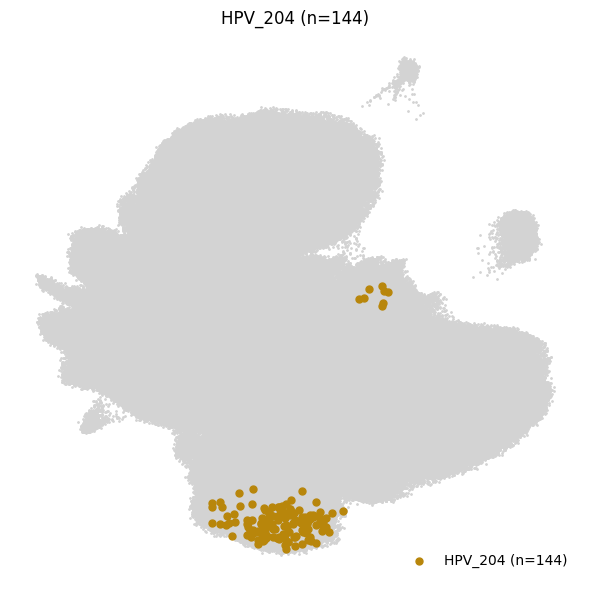

In [129]:
plot_motif_umap(adata, motif='204', color='darkgoldenrod', fg_size=25, save=save_dir+'T_CD8_motif_HPV_204.pdf')

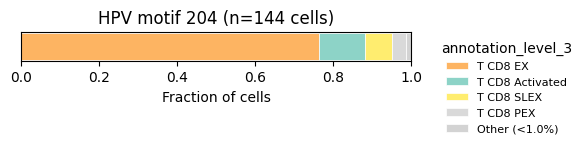

In [130]:
plot_annotation_barplot(adata, motifs='204',
                        figsize=(6, 1.25),
                        title='HPV motif 204',
                        save=save_dir+'barplot_HPV_204.pdf')

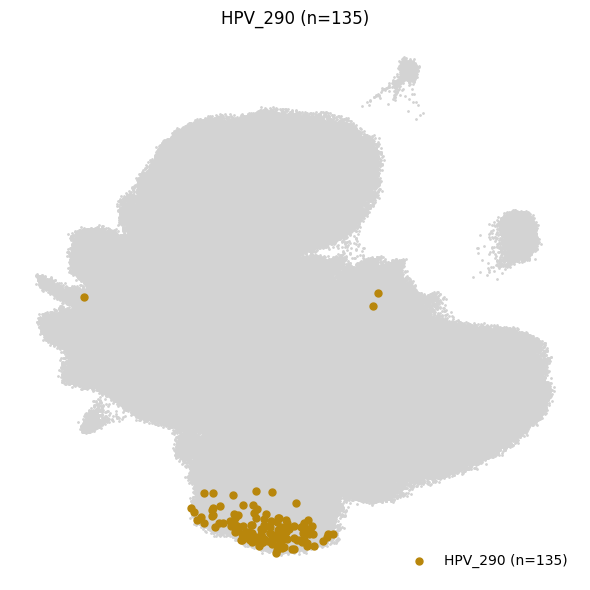

In [131]:
plot_motif_umap(adata, motif='290', color='darkgoldenrod', fg_size=25, save=save_dir+'T_CD8_motif_HPV_290.pdf')

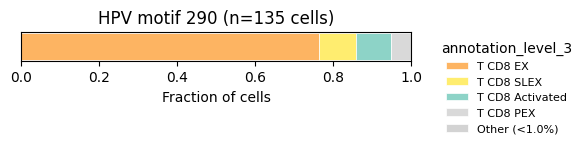

In [132]:
plot_annotation_barplot(adata, motifs='290',
                        figsize=(6, 1.25),
                        title='HPV motif 290',
                        save=save_dir+'barplot_HPV_290.pdf')

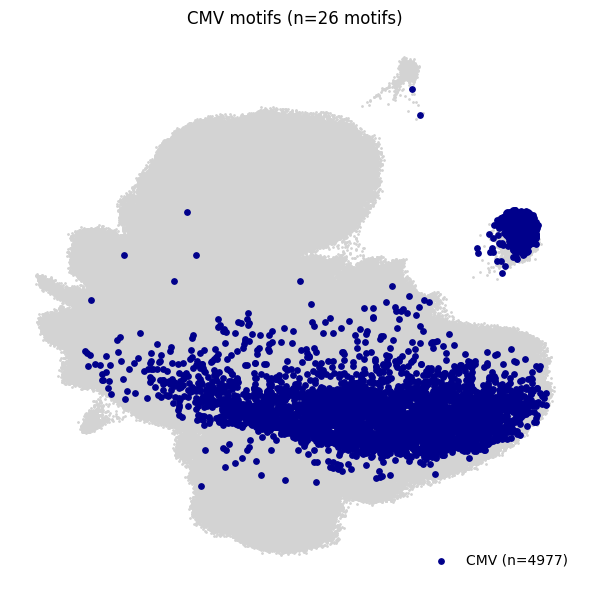

In [99]:
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']

sars_motifs = [m for m, p in motif_to_pathogen.items() if p == 'CMV']
mask_all = adata.obs['motif'].isin(sars_motifs)

# background
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)

# all SARS-CoV-2 motif cells on top
ax.scatter(umap_coords[mask_all, 0], umap_coords[mask_all, 1],
           s=15, color='darkblue', zorder=3,
           label=f'CMV (n={mask_all.sum()})')

ax.legend(frameon=False, loc='lower right')
ax.set_title(f'CMV motifs (n={len(sars_motifs)} motifs)')
ax.axis('off')
plt.tight_layout()
#plt.savefig(save_dir+'T_CD8_motif_Influenza_virus_all.pdf', dpi=150, bbox_inches='tight')
plt.show()

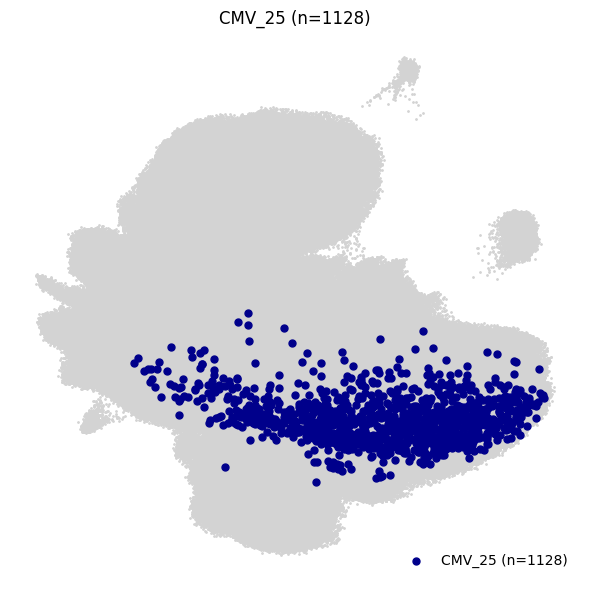

In [198]:
plot_motif_umap(adata, motif='25', color='darkblue', fg_size=25, save=save_dir+'T_CD8_motif_CMV.pdf')

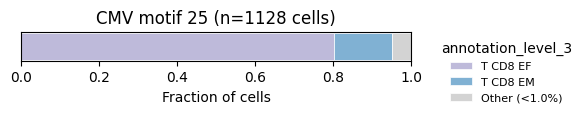

In [133]:
plot_annotation_barplot(adata, motifs='25',
                        figsize=(6, 1.25),
                        title='CMV motif 25',
                        save=save_dir+'barplot_CMV_25.pdf')

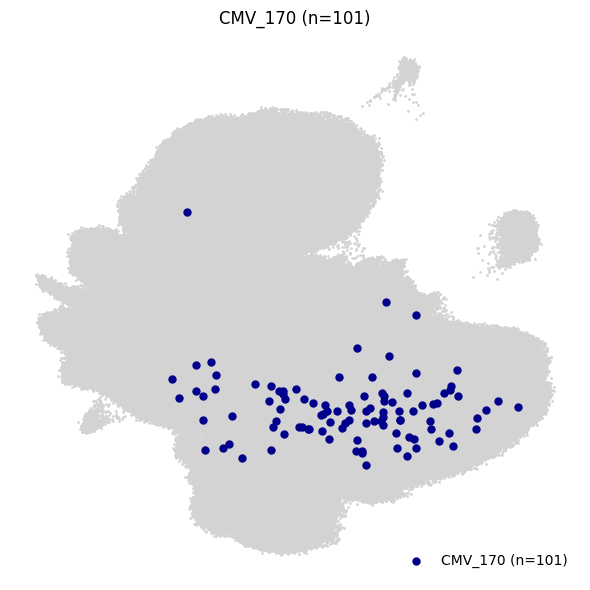

In [146]:
plot_motif_umap(adata, motif='170', color='darkblue', fg_size=25, save=save_dir+'T_CD8_motif_CMV_170.pdf')

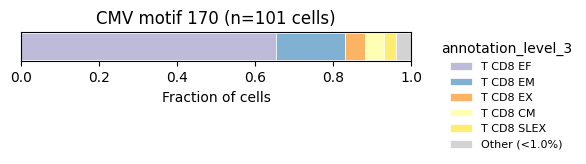

In [147]:
plot_annotation_barplot(adata, motifs='170',
                        figsize=(6, 1.25),
                        title='CMV motif 170',
                        save=save_dir+'barplot_CMV_170.pdf')

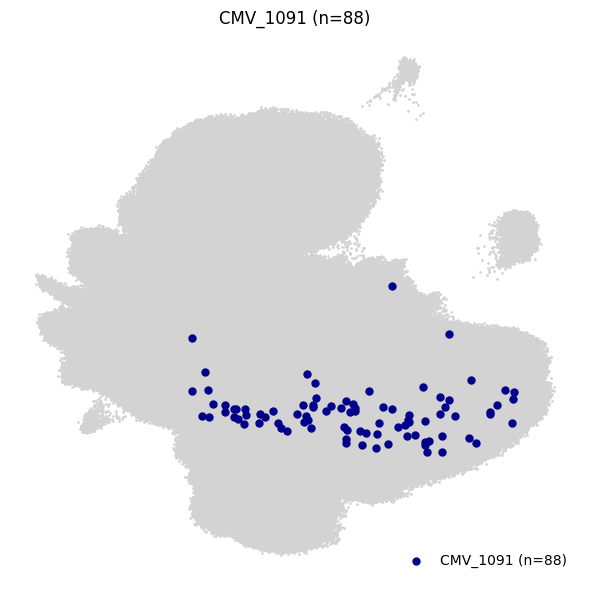

In [148]:
plot_motif_umap(adata, motif='1091', color='darkblue', fg_size=25, save=save_dir+'T_CD8_motif_CMV_1091.pdf')

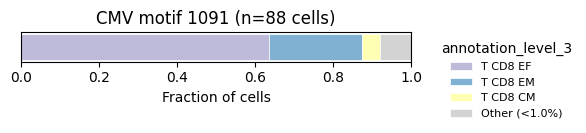

In [149]:
plot_annotation_barplot(adata, motifs='1091',
                        figsize=(6, 1.25),
                        title='CMV motif 1091',
                        save=save_dir+'barplot_CMV_1091.pdf')

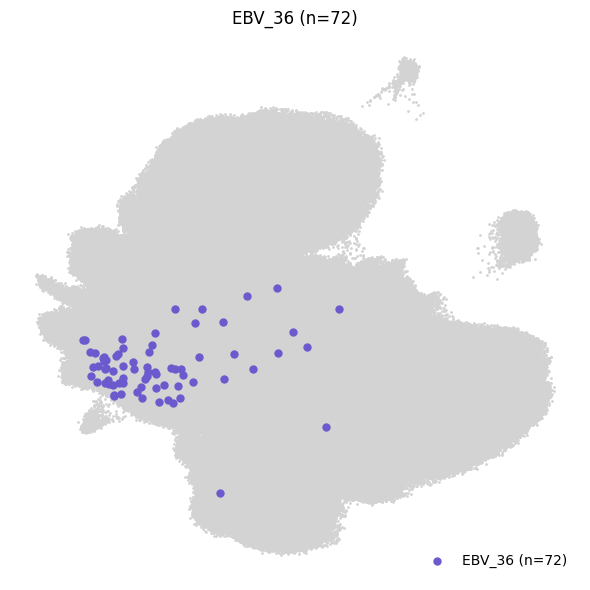

In [199]:
plot_motif_umap(adata, motif='36', color='slateblue', fg_size=25, save=save_dir+'T_CD8_motif_EBV.pdf')

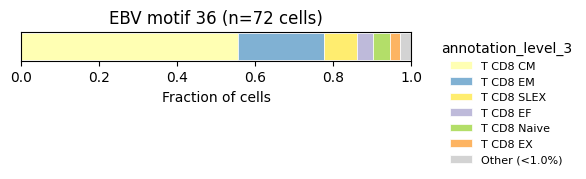

In [134]:
plot_annotation_barplot(adata, motifs='36',
                        figsize=(6, 1.25),
                        title='EBV motif 36',
                        save=save_dir+'barplot_EBV_36.pdf')

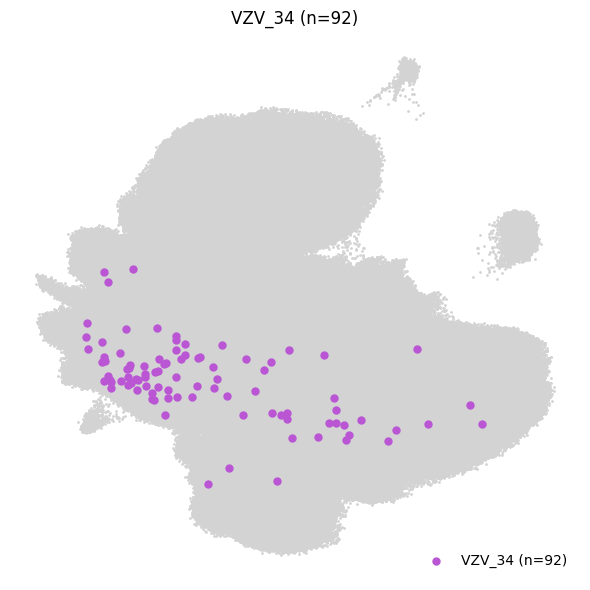

In [200]:
plot_motif_umap(adata, motif='34', color='mediumorchid', fg_size=25, save=save_dir+'T_CD8_motif_VZV.pdf')

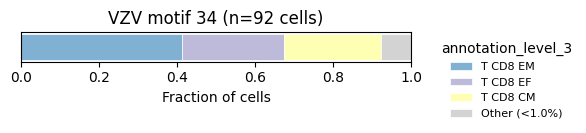

In [141]:
plot_annotation_barplot(adata, motifs='34',
                        figsize=(6, 1.25),
                        title='VZV motif 34',
                        save=save_dir+'barplot_VZV_34.pdf')

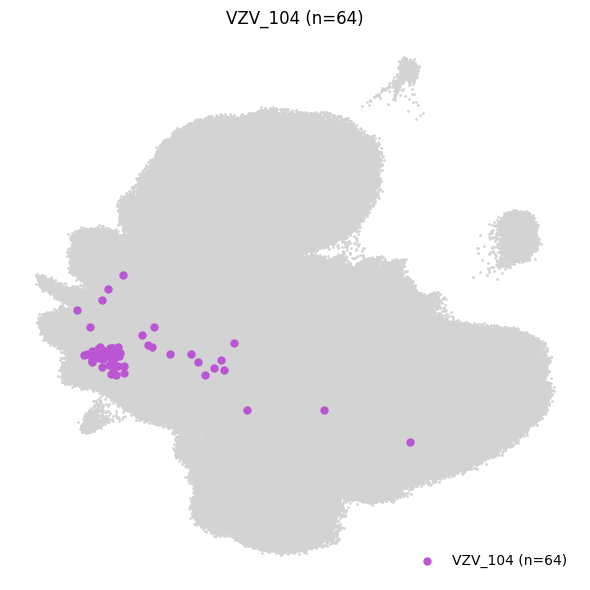

In [137]:
plot_motif_umap(adata, motif='104', color='mediumorchid', fg_size=25, save=save_dir+'T_CD8_motif_VZV_104.pdf')

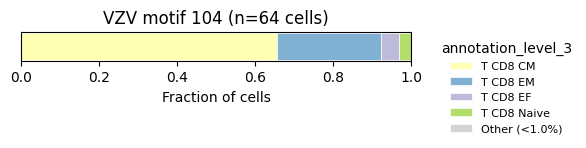

In [142]:
plot_annotation_barplot(adata, motifs='104',
                        figsize=(6, 1.25),
                        title='VZV motif 104',
                        save=save_dir+'barplot_VZV_104.pdf')

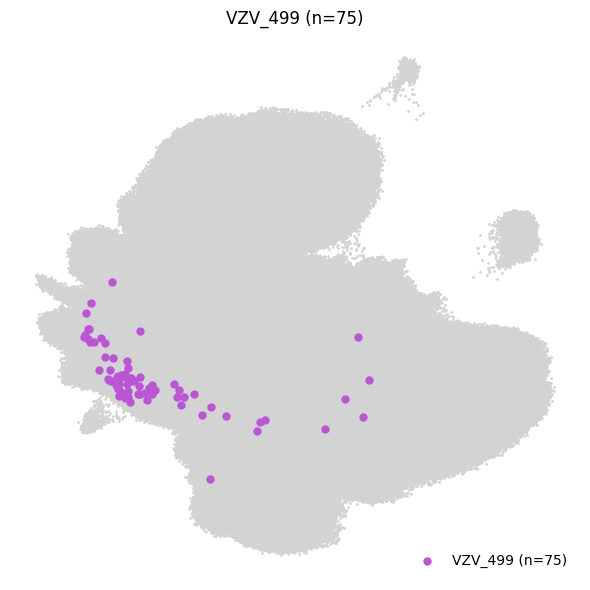

In [138]:
plot_motif_umap(adata, motif='499', color='mediumorchid', fg_size=25, save=save_dir+'T_CD8_motif_VZV_499.pdf')

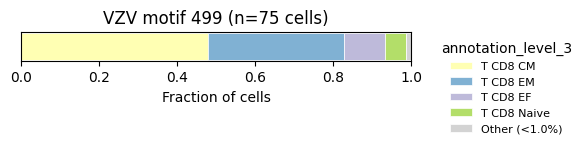

In [143]:
plot_annotation_barplot(adata, motifs='499',
                        figsize=(6, 1.25),
                        title='VZV motif 499',
                        save=save_dir+'barplot_VZV_499.pdf')

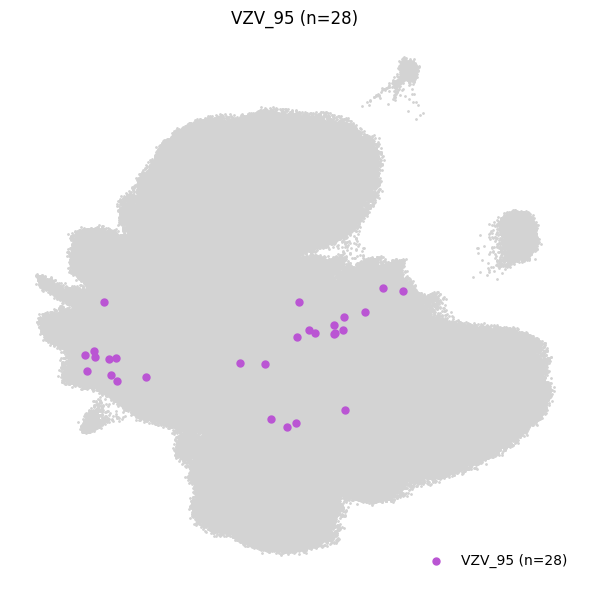

In [139]:
plot_motif_umap(adata, motif='95', color='mediumorchid', fg_size=25, save=save_dir+'T_CD8_motif_VZV_95.pdf')

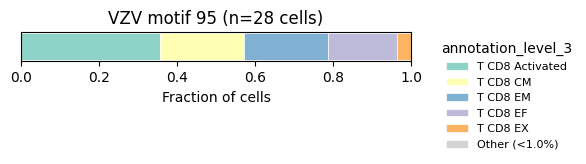

In [140]:
plot_annotation_barplot(adata, motifs='95',
                        figsize=(6, 1.25),
                        title='VZV motif 95',
                        save=save_dir+'barplot_VZV_95.pdf')

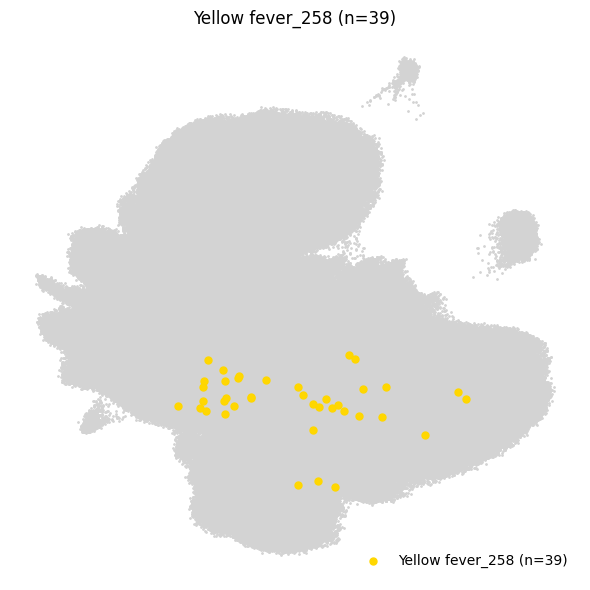

In [21]:
plot_motif_umap(adata, motif='258', color='gold', fg_size=25, save=save_dir+'T_CD8_motif_Yellow_fever_258.pdf')

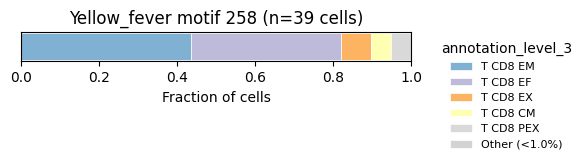

In [22]:
plot_annotation_barplot(adata, motifs='258',
                        figsize=(6, 1.25),
                        title='Yellow_fever motif 258',
                        save=save_dir+'barplot_Yellow_fever_258.pdf')

In [18]:
yf_motifs = [m for m, p in motif_to_pathogen.items() if p == 'Yellow fever']
print(f"Yellow fever motifs: {yf_motifs}")

results = []
for motif in yf_motifs:
    mask = adata.obs['motif'] == motif
    n_cells = mask.sum()
    
    if n_cells == 0:
        print(f"Motif {motif}: no cells found, skipping")
        continue
    
    annot_counts = adata.obs[mask]['annotation_level_3'].value_counts()
    annot_frac = annot_counts / n_cells
    
    results.append({
        'motif': motif,
        'pathogen': 'Yellow fever',
        'n_cells': n_cells,
        'frac_T_query': annot_frac.get('T CD8 Activated', 0),
        'top_annotation': annot_counts.index[0],
        'annotation_breakdown': annot_frac.to_dict()
    })

if len(results) == 0:
    print("No cells found for any Yellow fever motif")
else:
    results_yf_df = pd.DataFrame(results).sort_values('frac_T_query', ascending=False)
    pd.set_option('display.max_rows', None)
    print(results_yf_df[['motif', 'n_cells', 'frac_T_query', 'top_annotation']])
    pd.reset_option('display.max_rows')

Yellow fever motifs: ['258', '145']
  motif  n_cells  frac_T_query   top_annotation
1   145        2           0.5  T CD8 Activated
0   258       39           0.0         T CD8 EM


# 2. Prepare CD4 T cell plots

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata_CD4.h5ad')
adata

AnnData object with n_obs × n_vars = 2088298 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/CD4_umap_neighbors_15_min_dist_1.3.npy')
adata.obsm["X_umap"] = UMAP

In [3]:
motif_df=pd.read_csv("/rfs/project/rfs-iCNyzSAaucw/lmd76/code_hpc/data/disease_associated_motifs_hla.csv", index_col='Unnamed: 0')
motif_df

,motif,n_cells,n_unique_vdj_clones,n_beam_cells,n_donors,n_studies,majority_pathogen,majority_pathogen_unique_clone_frac,majority_annotation,majority_annotation_all_cells_frac,...,majority_vdjdb_organism,n_vdjdb_epitopes,majority_beam_epitope,majority_beam_organism,majority_beam_cells_frac,MHC_I_restricted_allele,MHC_II_restricted_allele,majority_vdjdb_organism_simple,predicted_pathogen,predicted_pathogen_source
0,592,3099,2,544,6,2,EBV_VZV,0.500000,T CD8 EF,0.964557,...,NaN,NaN,IE62,VZV,0.505515,Multiple,Multiple,NaN,VZV,beam
1,37,2729,43,11,41,12,SARS-CoV-2,0.490196,T CD8 EF,0.843166,...,Human herpesvirus 5 (Human cytomegalovirus),2.0,NLVPMVATV,CMV,1.000000,A*02:01,Not restricted,CMV,CMV,beam
2,61,2714,17,0,6,1,HPV,1.000000,T CD8 EX,0.771186,...,SARS-CoV2,1.0,NaN,NaN,NaN,Not restricted,Not restricted,SARS-CoV-2,HPV,majority_pathogen
8,565,1444,1,0,6,2,SARS-CoV-2,1.000000,T CD8 EF,0.922438,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Not restricted,NaN,SARS-CoV-2,majority_pathogen
10,25,1156,82,0,73,10,SARS-CoV-2,0.507246,T CD8 EF,0.782872,...,Human herpesvirus 5 (strain RV798),8.0,NaN,NaN,NaN,Not restricted,Not restricted,CMV,CMV,vdjdb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1115,4,1,0,4,2,NaN,0.000000,T CD4 CM,1.000000,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Multiple,NaN,NaN,NaN
1064,1124,4,1,0,4,3,SARS-CoV-2,1.000000,T CD4 CM,0.500000,...,SARS-CoV2,1.0,NaN,NaN,NaN,C*07:02,DRB1*15:01,SARS-CoV-2,SARS-CoV-2,majority_pathogen
1067,1223,4,1,0,4,4,SARS-CoV-2,0.500000,T CD8 CM,0.666667,...,SARS-CoV2,1.0,NaN,NaN,NaN,Multiple,Not restricted,SARS-CoV-2,SARS-CoV-2,vdjdb
1068,1243,4,1,0,4,1,SARS-CoV-2,1.000000,T CD8 EF,0.750000,...,NaN,NaN,NaN,NaN,NaN,Not restricted,Not restricted,NaN,SARS-CoV-2,majority_pathogen


In [7]:
cols=motif_df.columns
print(cols)

Index(['motif', 'n_cells', 'n_unique_vdj_clones', 'n_beam_cells', 'n_donors',
       'n_studies', 'majority_pathogen', 'majority_pathogen_unique_clone_frac',
       'majority_annotation', 'majority_annotation_all_cells_frac',
       'naive_annotation_all_cells_frac', 'healthy_unique_donor_frac',
       'majority_vdjdb_epitope', 'majority_vdjdb_organism', 'n_vdjdb_epitopes',
       'majority_beam_epitope', 'majority_beam_organism',
       'majority_beam_cells_frac', 'MHC_I_restricted_allele',
       'MHC_II_restricted_allele', 'majority_vdjdb_organism_simple',
       'predicted_pathogen', 'predicted_pathogen_source'],
      dtype='object')


In [8]:
motif_df['majority_annotation'].unique().tolist()

['T CD8 EF',
 'T CD8 EX',
 nan,
 'T CD8 EM',
 'T CD8 Activated',
 'T CD4 CM',
 'T CD4 CTL',
 'T CD8 CM',
 'T CD8 PEX',
 'T CD8 RM',
 'T CD4 Activated CTL',
 'T CD8 SLEX',
 'T CD4 Activated',
 'T CD4 PH',
 'T CD4 EF',
 'T G/D Vd2 EM']

In [6]:
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection_cell2tcr/cell2tcr_job/clone_df_with_motif_21.csv', index_col='Unnamed: 0')
#adata = adata[adata.obs_names.isin(df.index)]
#adata.obs['motif'] = df.loc[adata.obs_names, 'motif'].values

adata.obs['motif'] = df['motif'].reindex(adata.obs_names).values

/tmp/ipykernel_1791540/3504749257.py:1: DtypeWarning: Columns (13,15,17,19,23,24,25,28,29,30,40,42,50,54,56,61,62,63,64,67,68,70,71,72,73,75,76,77,79,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection_cell2tcr/cell2tcr_job/clone_df_with_motif_21.csv', index_col='Unnamed: 0')


In [7]:
adata.obs['predicted_pathogen'] = adata.obs['motif'].map(
    motif_df.set_index('motif')['predicted_pathogen']
)

In [8]:
adata.obs['motif'] = df['motif'].reindex(adata.obs_names).astype('Int64').astype(str).replace('<NA>', 'nan').values

In [9]:
motif_to_pathogen = (
    adata.obs[['motif', 'predicted_pathogen']]
    .drop_duplicates('motif')
    .set_index('motif')['predicted_pathogen']
    .to_dict()
)

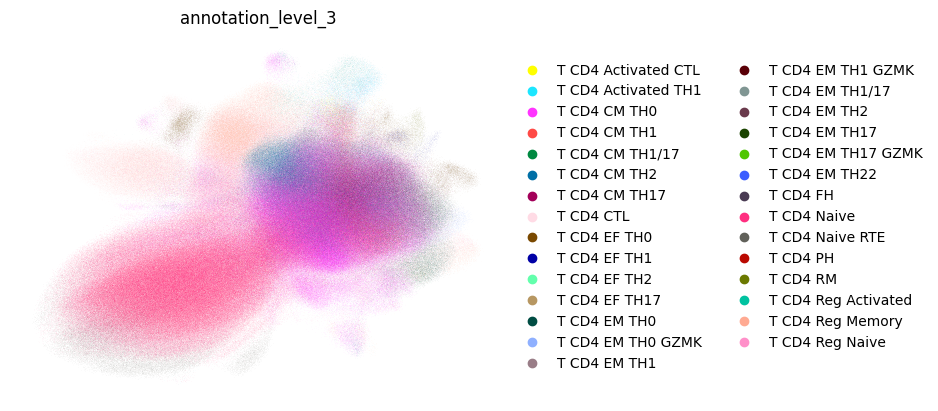

In [10]:
sc.pl.umap(adata, color='annotation_level_3', frameon=False)

- Define query functions to visualise pathogen-associated TCR motifs:

In [14]:
def plot_motif_umap(adata, motif, color='purple', fg_size=25,
                    title=None, save=None, figsize=(6,6), ax=None):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    umap_coords = adata.obsm['X_umap']
    mask = adata.obs['motif'].values == motif
    
    # background - only plot if no ax passed in
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
               s=bg_size, color='lightgrey', rasterized=True)
    
    # overlay motif cells
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               s=fg_size, color=color, zorder=3,
               label=f'{motif_to_pathogen.get(motif, "")}_{motif} (n={mask.sum()})')
    
    ax.legend(frameon=False, loc='lower right')
    ax.set_title(title or f'{motif_to_pathogen.get(motif, "")}_{motif}')
    ax.axis('off')
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


# pre-render background once, then reuse
fig, ax = plt.subplots(figsize=(6, 6))
umap_coords = adata.obsm['X_umap']
ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
           s=1, color='lightgrey', rasterized=True)
ax.axis('off')

# save background figure to reuse
import pickle
with open('/tmp/bg_fig.pkl', 'wb') as f:
    pickle.dump(fig, f)
plt.close()

# usage - loads background and overlays motif
def plot_motif_umap(adata, motif, color='purple', fg_size=25,
                    title=None, save=None):
    
    with open('/tmp/bg_fig.pkl', 'rb') as f:
        fig = pickle.load(f)
    ax = fig.axes[0]
    
    umap_coords = adata.obsm['X_umap']
    mask = adata.obs['motif'].values == motif
    label = f'{motif_to_pathogen.get(motif, "")}_{motif} (n={mask.sum()})'
    
    scatter = ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                         s=fg_size, color=color, zorder=3, label=label)
    
    ax.legend(frameon=False, loc='lower right')
    ax.set_title(title or label)
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    
    # remove overlay for next call
    scatter.remove()
    if ax.get_legend():
        ax.get_legend().remove()

In [15]:
import matplotlib.cm as cm

cats = adata.obs['annotation_level_3'].cat.categories.tolist()

# generate custom colors for all categories
custom_colors = cm.tab20b(np.linspace(0, 1, len(cats)))
color_map = dict(zip(cats, custom_colors))
color_map['Other (<1.0%)'] = 'lightgrey'

def plot_annotation_barplot(adata, motifs, title='', figsize=(6, 3), save=None, min_frac=0.025):
    """
    Plot annotation_level_3 horizontal stacked barplot for a list of motifs.
    motifs: list of motif IDs or a single motif string
    """
    if isinstance(motifs, str):
        motifs = [motifs]
    
    mask = adata.obs['motif'].isin(motifs)
    counts = adata.obs[mask]['annotation_level_3'].value_counts()
    fracs = counts / counts.sum()
    
    # collapse rare categories
    major = fracs[fracs >= min_frac]
    rare = fracs[fracs < min_frac]
    if len(rare) > 0:
        major['Other (<1.0%)'] = rare.sum()
    
    fig, ax = plt.subplots(figsize=figsize)
    left = 0
    for cat, val in major.items():
        color = color_map.get(cat, 'lightgrey')
        ax.barh(0, val, left=left, color=color,
                edgecolor='white', linewidth=0.5, label=cat)
        left += val
    
    ax.set_xlabel('Fraction of cells')
    ax.set_title(f'{title} (n={mask.sum()} cells)')
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.legend(bbox_to_anchor=(1.05, 1), frameon=False,
              title='annotation_level_3', fontsize=8)
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

- Ext Data Fig. 4d

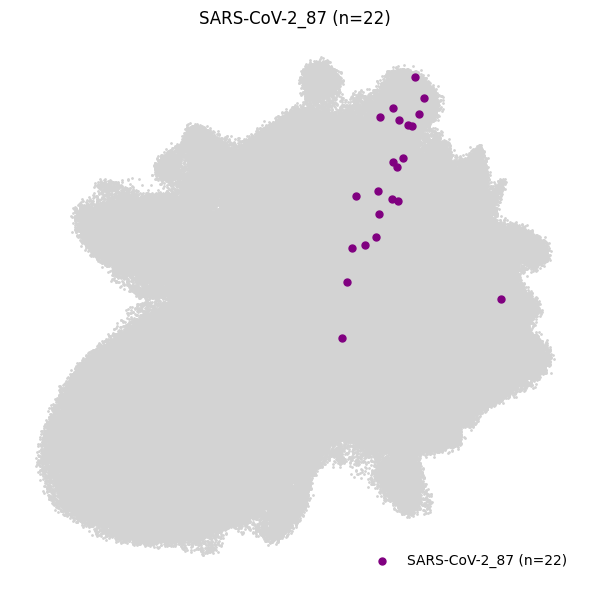

In [180]:
plot_motif_umap(adata, motif='87', color='purple', fg_size=25, save=save_dir+'T_CD4_motif_SARS_CoV_2_87.pdf')

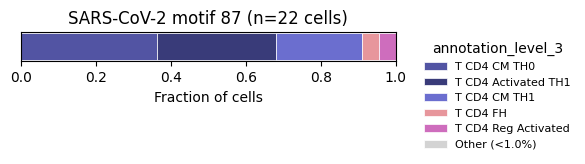

In [181]:
plot_annotation_barplot(adata, motifs='87',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 87',
                        save=save_dir+'barplot_SARS_CoV_2_87.pdf')

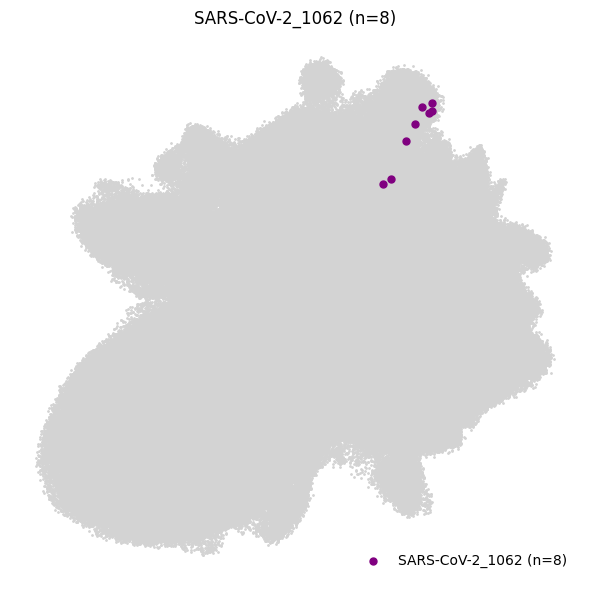

In [188]:
plot_motif_umap(adata, motif='1062', color='purple', fg_size=25, save=save_dir+'T_CD4_motif_SARS_CoV_2_1062.pdf')

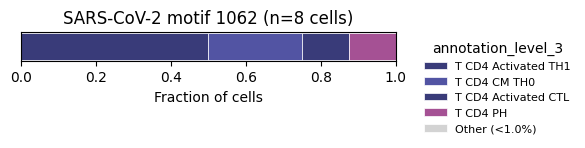

In [189]:
plot_annotation_barplot(adata, motifs='1062',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 1062',
                        save=save_dir+'barplot_SARS_CoV_2_1062.pdf')

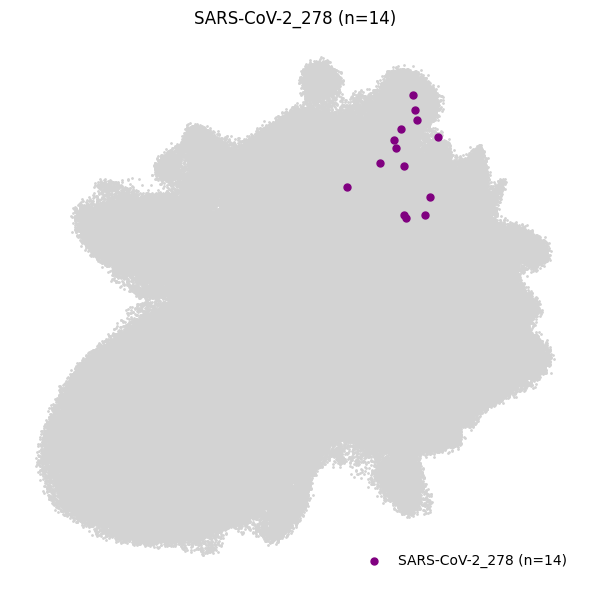

In [17]:
plot_motif_umap(adata, motif='278', color='purple', fg_size=25, save=save_dir+'T_CD4_motif_SARS_CoV_2_278.pdf')

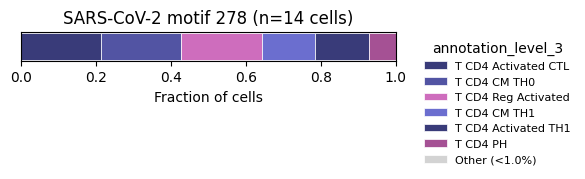

In [18]:
plot_annotation_barplot(adata, motifs='278',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 278',
                        save=save_dir+'barplot_SARS_CoV_2_278.pdf')

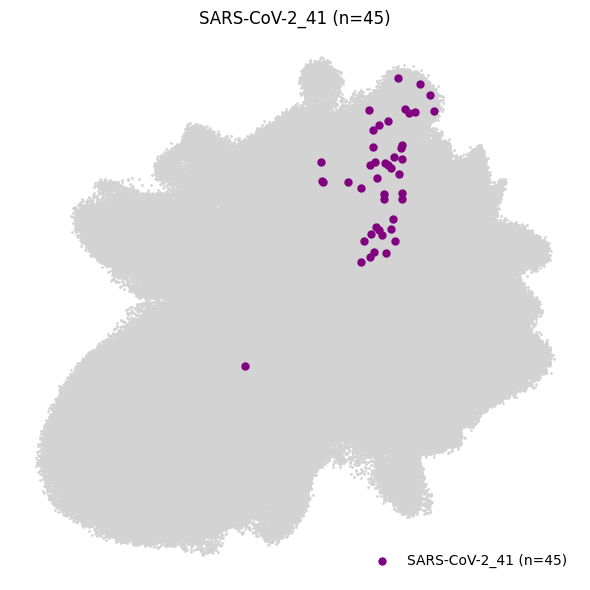

In [194]:
plot_motif_umap(adata, motif='41', color='purple', fg_size=25)
                
                
#save=save_dir+'T_CD4_motif_SARS_CoV_2_1062.pdf')

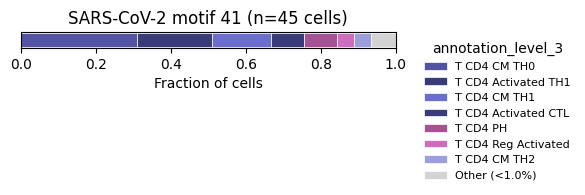

In [195]:
plot_annotation_barplot(adata, motifs='41',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 41')

#save=save_dir+'barplot_SARS_CoV_2_1062.pdf'

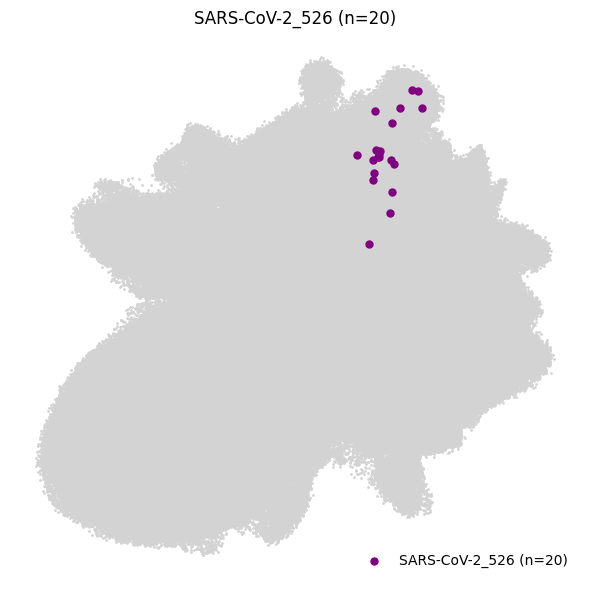

In [62]:
plot_motif_umap(adata, motif='526', color='purple', fg_size=25,save=save_dir+'T_CD4_motif_SARS_CoV_2_526.pdf')

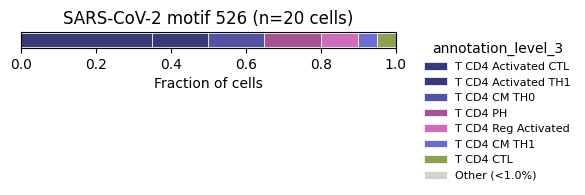

In [61]:
plot_annotation_barplot(adata, motifs='526',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 526',
                        save=save_dir+'barplot_SARS_CoV_2_526.pdf')

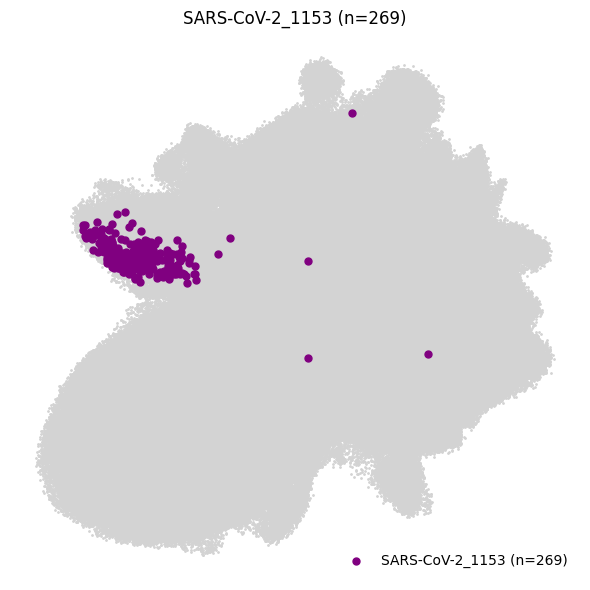

In [59]:
plot_motif_umap(adata, motif='1153', color='purple', fg_size=25, save=save_dir+'T_CD4_motif_SARS_CoV_2_1153.pdf')

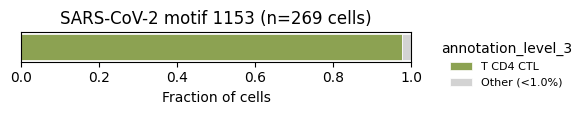

In [60]:
plot_annotation_barplot(adata, motifs='1153',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 1153',
                        save=save_dir+'barplot_SARS_CoV_2_1153.pdf')

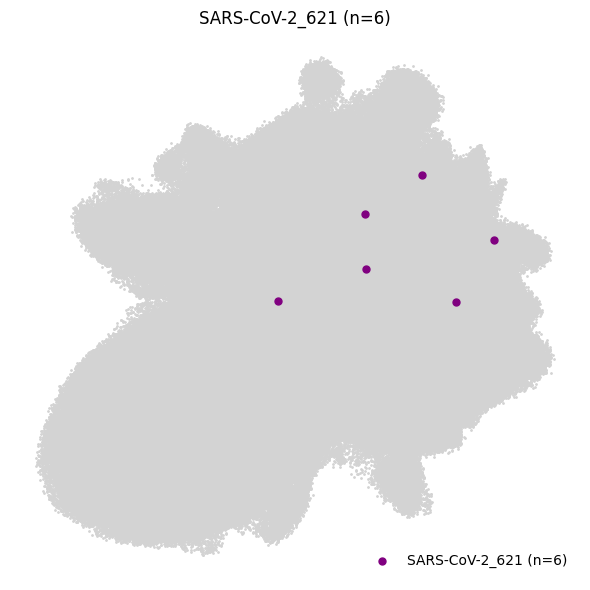

In [65]:
plot_motif_umap(adata, motif='621', color='purple', fg_size=25, save=save_dir+'T_CD4_motif_SARS_CoV_2_621.pdf')

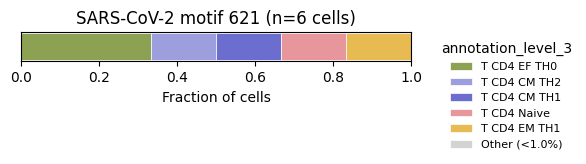

In [66]:
plot_annotation_barplot(adata, motifs='621',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 621',
                        save=save_dir+'barplot_SARS_CoV_2_621.pdf')

In [ ]:
25    381       11      0.090909         T CD4 CM TH0
170   982       11      0.090909         T CD4 CM TH0
189    71       19      0.052632          T CD4 Naive
156   111       20      0.050000         T CD4 CM TH0
169   310       26      0.038462            T CD4 CTL
202   122       32      0.031250            T CD4 CTL

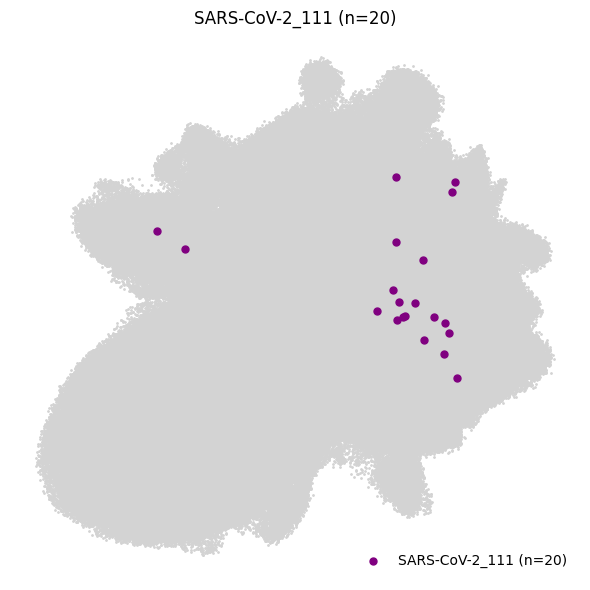

In [80]:
plot_motif_umap(adata, motif='111', color='purple', fg_size=25)
                
                
#save=save_dir+'T_CD4_motif_SARS_CoV_2_1062.pdf')

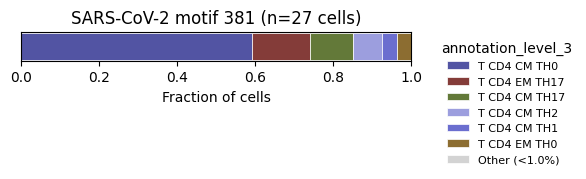

In [84]:
plot_annotation_barplot(adata, motifs='80',
                        figsize=(6, 1.25),
                        title='SARS-CoV-2 motif 381')

#save=save_dir+'barplot_SARS_CoV_2_1062.pdf'

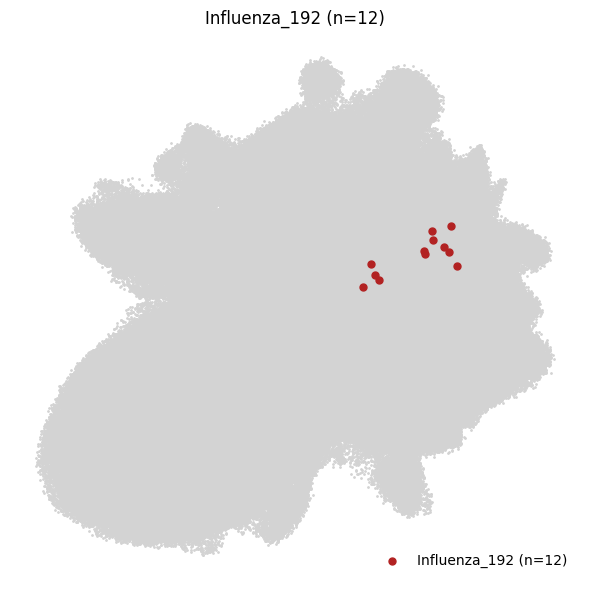

In [215]:
plot_motif_umap(adata, motif='192', color='firebrick', fg_size=25)
                
#save=save_dir+'T_CD4_motif_HIV_563.pdf')

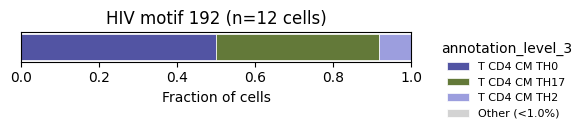

In [214]:
plot_annotation_barplot(adata, motifs='192',
                        figsize=(6, 1.25),
                        title='HIV motif 192')
#                        save=save_dir+'barplot_HIV_563.pdf')

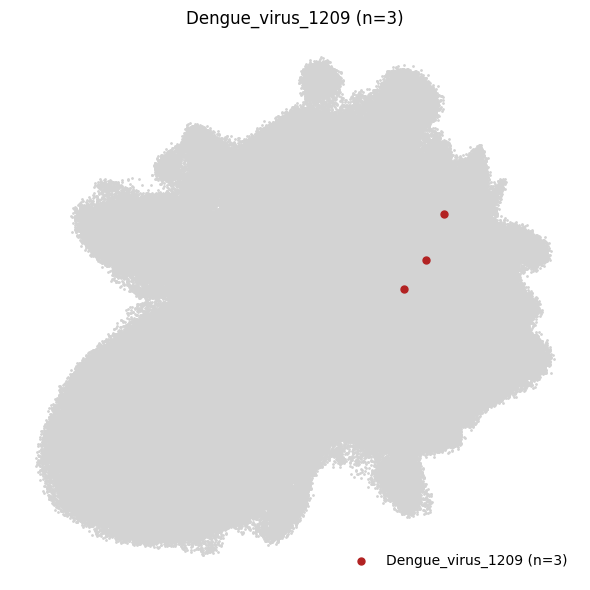

In [220]:
plot_motif_umap(adata, motif='1209', color='firebrick', fg_size=25)
                
#save=save_dir+'T_CD4_motif_HIV_563.pdf')

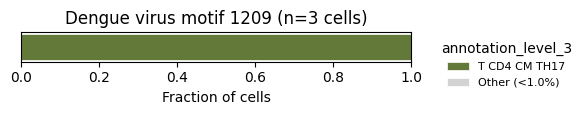

In [222]:
plot_annotation_barplot(adata, motifs='1209',
                        figsize=(6, 1.25),
                        title='Dengue virus motif 1209')
#                        save=save_dir+'barplot_HIV_563.pdf')

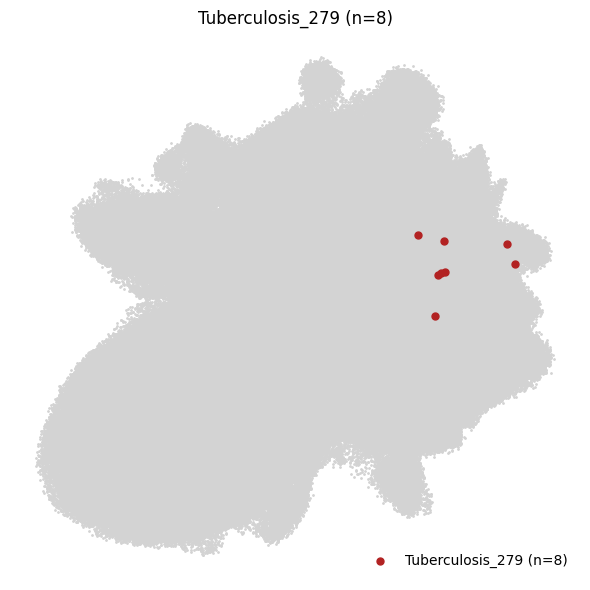

In [229]:
plot_motif_umap(adata, motif='279', color='firebrick', fg_size=25)
                
#save=save_dir+'T_CD4_motif_HIV_563.pdf')

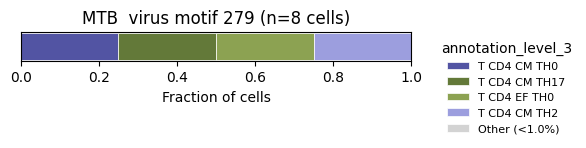

In [230]:
plot_annotation_barplot(adata, motifs='279',
                        figsize=(6, 1.25),
                        title='MTB  virus motif 279')
#                        save=save_dir+'barplot_HIV_563.pdf')

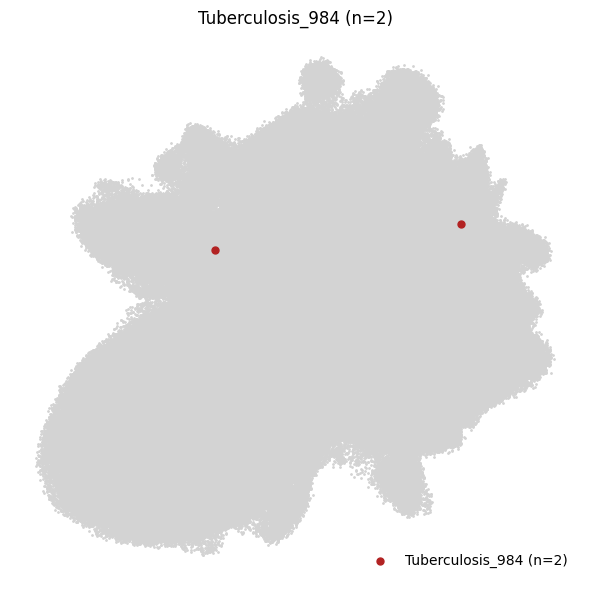

In [227]:
plot_motif_umap(adata, motif='984', color='firebrick', fg_size=25)
                
#save=save_dir+'T_CD4_motif_HIV_563.pdf')

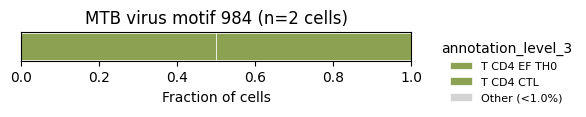

In [228]:
plot_annotation_barplot(adata, motifs='984',
                        figsize=(6, 1.25),
                        title='MTB virus motif 984')
#                        save=save_dir+'barplot_HIV_563.pdf')

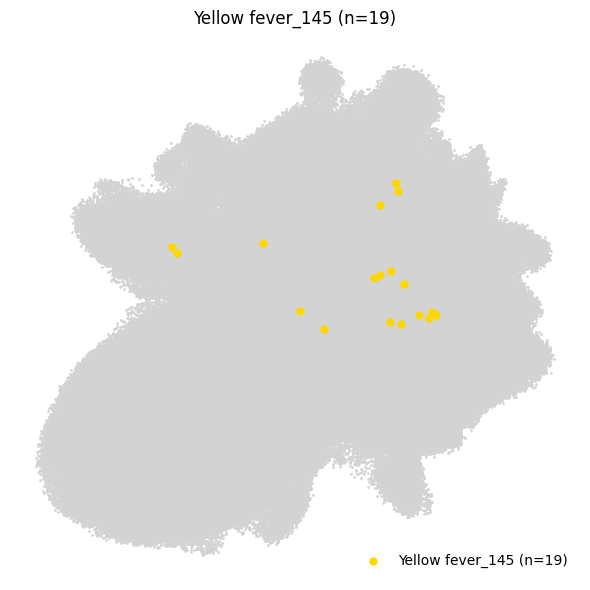

In [85]:
plot_motif_umap(adata, motif='145', color='gold', fg_size=25, save=save_dir+'T_CD4_motif_Yellow_fever_145.pdf')

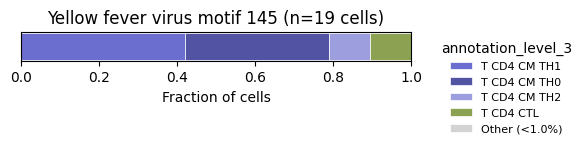

In [86]:
plot_annotation_barplot(adata, motifs='145',
                        figsize=(6, 1.25),
                        title='Yellow fever virus motif 145',
                        save=save_dir+'barplot_Yellow_fever_145.pdf')